In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/radioml2018/datasets.desktop
/kaggle/input/radioml2018/classes-fixed.json
/kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
/kaggle/input/radioml2018/classes-fixed.txt
/kaggle/input/radioml2018/LICENSE.TXT
/kaggle/input/radioml2018/classes.txt


#  **List Files in the Dataset Directory**

In [2]:
import os

dataset_path = '/kaggle/input/radioml2018'
print(os.listdir(dataset_path))

['datasets.desktop', 'classes-fixed.json', 'GOLD_XYZ_OSC.0001_1024.hdf5', 'classes-fixed.txt', 'LICENSE.TXT', 'classes.txt']


In [3]:
import h5py
import os

# Define the path to the dataset directory
dataset_dir = '/kaggle/input/radioml2018'

# Find the HDF5 file in the directory
# This makes the code robust even if the filename changes slightly
h5_filename = ''
for file in os.listdir(dataset_dir):
    if file.endswith('.h5') or file.endswith('.hdf5'):
        h5_filename = file
        break

if h5_filename:
    # Construct the full, correct file path
    full_path = os.path.join(dataset_dir, h5_filename)
    print(f"Found HDF5 file: {full_path}")

    try:
        # Load the HDF5 file
        with h5py.File(full_path, 'r') as f:
            print("File opened successfully!")
            # You can now access your data, e.g., print keys
            print("Keys in file:", list(f.keys()))
            # X = f['X'][:]
            # Y = f['Y'][:]
            # Snrs = f['Snrs'][:]
    except Exception as e:
        print(f"An error occurred while loading the file: {e}")
else:
    print("No HDF5 file found in the directory.")

Found HDF5 file: /kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
File opened successfully!
Keys in file: ['X', 'Y', 'Z']


# **Loading the data from the HDF5 file into NumPy arrays and check their shapes.{Load Data into Variables & Explore}** # 

In [4]:
import h5py
import numpy as np

full_path = '/kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5'

# Define how many samples you want to load for now
num_samples_to_load = 200000

with h5py.File(full_path, 'r') as f:
    # Slice the data to only load the first num_samples_to_load
    X = f['X'][:num_samples_to_load]  # IQ data
    Y = f['Y'][:num_samples_to_load]  # Labels
    Z = f['Z'][:num_samples_to_load]  # SNR values

print(f"Successfully loaded {num_samples_to_load} samples.")
print("Shape of X (features):", X.shape)
print("Shape of Y (labels):", Y.shape)
print("Shape of Z (SNR values):", Z.shape)

Successfully loaded 200000 samples.
Shape of X (features): (200000, 1024, 2)
Shape of Y (labels): (200000, 24)
Shape of Z (SNR values): (200000, 1)


In [5]:
type(X[:5])

numpy.ndarray

In [6]:
X[:2]

array([[[ 0.0420274 ,  0.23476323],
        [-0.2728826 ,  0.40513492],
        [-0.26707262,  0.22749889],
        ...,
        [-0.7055947 , -0.28693035],
        [-0.41157472,  0.66826206],
        [ 0.06487698,  0.6358149 ]],

       [[ 1.198624  ,  0.4493616 ],
        [ 0.48543093,  0.28272954],
        [ 0.8679219 , -0.33194578],
        ...,
        [-1.2129315 , -0.64293194],
        [-0.38100415,  0.793629  ],
        [ 0.0864124 ,  1.0921808 ]]], dtype=float32)

In [7]:
Y[:2]

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0]])

In [8]:
Z[:10]

array([[-20],
       [-20],
       [-20],
       [-20],
       [-20],
       [-20],
       [-20],
       [-20],
       [-20],
       [-20]])

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the modulation class names in their standard order
mod_classes = [
    'OOK', 'ASK4', 'ASK8', 'BPSK', 'QPSK', 'PSK8', 'PSK16', 'PSK32',
    'APSK16', 'APSK32', 'APSK64', 'APSK128', 'QAM16', 'QAM32', 'QAM64',
    'QAM128', 'QAM256', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC',
    'FM', 'GMSK', 'OQPSK'
]

#Right now, your labels (Y) are in a "one-hot encoded" format (e.g., [0, 0, 1, 0, ...]), 
#which is useful for machine learning but not for plotting
# Convert the one-hot encoded Y array to a list of label indices
# np.argmax finds the position of the '1' in each row
y_labels = np.argmax(Y, axis=1)

print("Labels are now decoded and ready for plotting.")

Labels are now decoded and ready for plotting.


# **DATA VISUALIZATION** #

# **1. Distribution of Modulation Types** # 

In [10]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

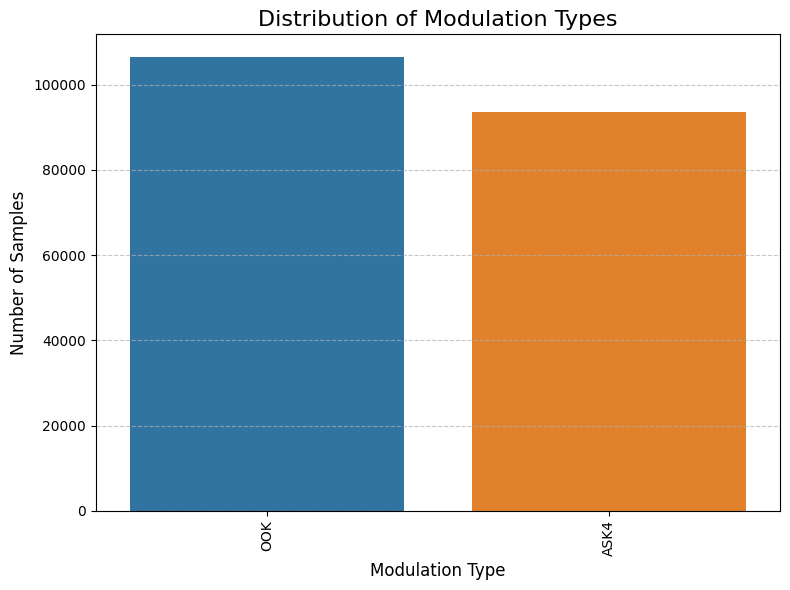

In [11]:
# Convert the list of label strings into a pandas Series
labels_series = pd.Series([mod_classes[i] for i in y_labels])

# Now, plot using the pandas Series
plt.figure(figsize=(8, 6))
sns.countplot(x=labels_series) # Use the new Series here
plt.title('Distribution of Modulation Types', fontsize=16)
plt.xlabel('Modulation Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

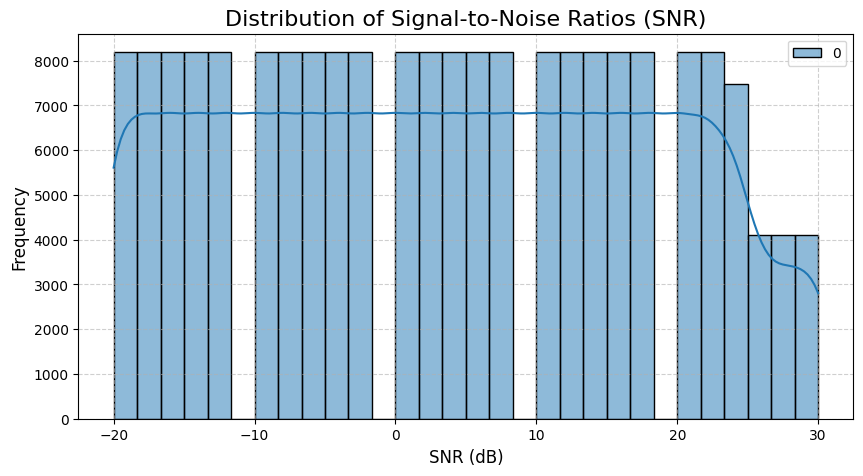

In [12]:
## Visualization 2: Distribution of SNR Values

plt.figure(figsize=(10, 5))
sns.histplot(Z, bins=30, kde=True)
plt.title('Distribution of Signal-to-Noise Ratios (SNR)', fontsize=16)
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
import numpy as np
print("Available SNR values in your data slice:", np.unique(Z))

Available SNR values in your data slice: [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


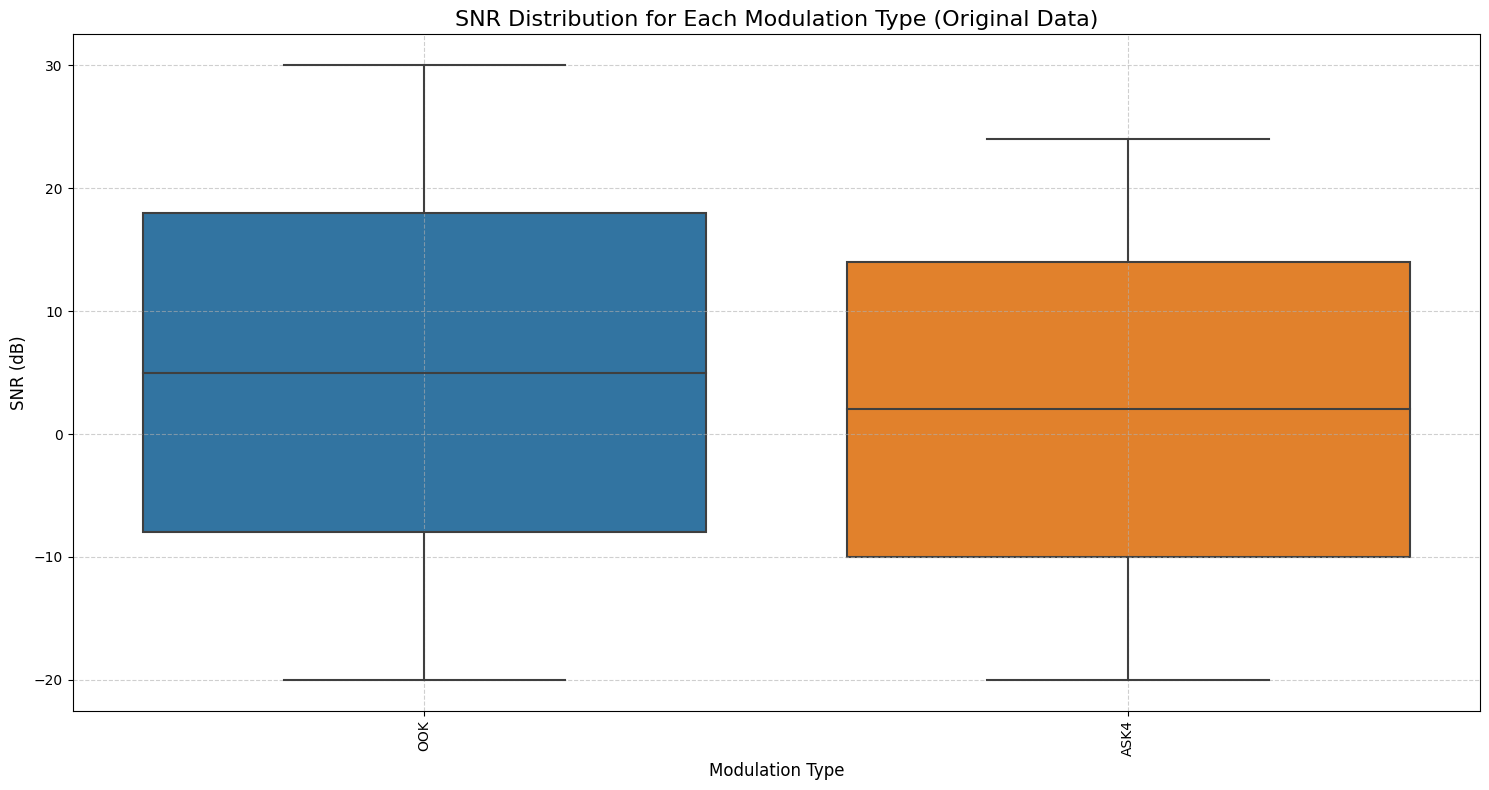

In [14]:
## Final Visualization: SNR Distribution for ALL Modulation Types

# IMPORTANT: This plot uses the original, unfiltered data (y_labels and Z)
# to show the complete picture.

# Create a pandas DataFrame for plotting
df_original = pd.DataFrame({
    'Modulation': [mod_classes[i] for i in y_labels],
    'SNR': Z.flatten()
})


plt.figure(figsize=(15, 8))
sns.boxplot(data=df_original, x='Modulation', y='SNR')
plt.title('SNR Distribution for Each Modulation Type (Original Data)', fontsize=16)
plt.xlabel('Modulation Type', fontsize=12)
plt.ylabel('SNR (dB)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

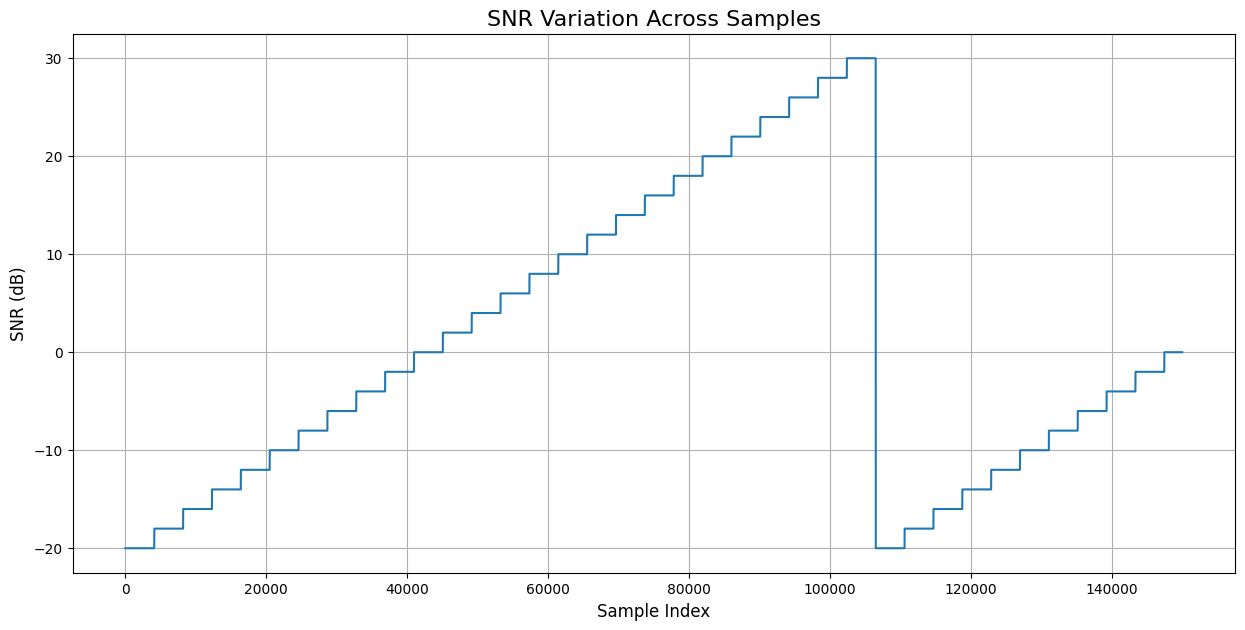

In [15]:
import matplotlib.pyplot as plt

samples_to_plot = 150000

plt.figure(figsize=(15, 7))
plt.plot(Z[:samples_to_plot])
plt.title('SNR Variation Across Samples', fontsize=16)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('SNR (dB)', fontsize=12)
plt.grid(True)
plt.show()

In [16]:
def get_best_sample_from_filtered(mod_type):
    mod_index = mod_classes.index(mod_type)
    
    all_indices = np.where(np.argmax(Y, axis=1) == mod_index)[0]
    
    if len(all_indices) == 0:
        print(f"Warning: No samples found for {mod_type} in the filtered data.")
        return None, None
        
    snrs_for_mod = Z[all_indices]
    best_sample_index_in_subset = np.argmax(snrs_for_mod)
    
    final_sample_index = all_indices[best_sample_index_in_subset]
    
    return X[final_sample_index], Z[final_sample_index].item()

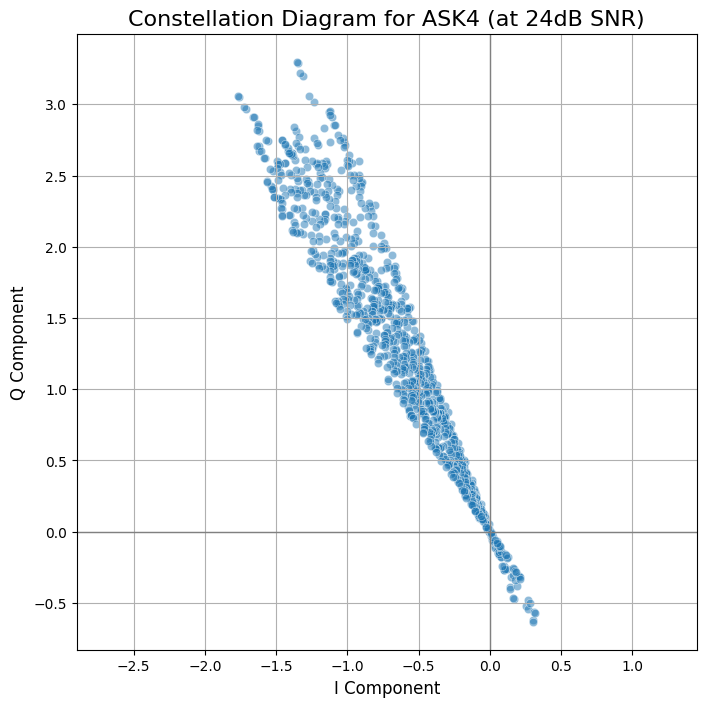

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_to_plot, snr = get_best_sample_from_filtered('ASK4')

if sample_to_plot is not None:
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=sample_to_plot[:, 0], y=sample_to_plot[:, 1], alpha=0.5)
    
    plt.title(f'Constellation Diagram for ASK4 (at {snr:.0f}dB SNR)', fontsize=16)
    plt.xlabel('I Component', fontsize=12)
    plt.ylabel('Q Component', fontsize=12)
    plt.grid(True)
    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    plt.axis('equal')
    plt.show()

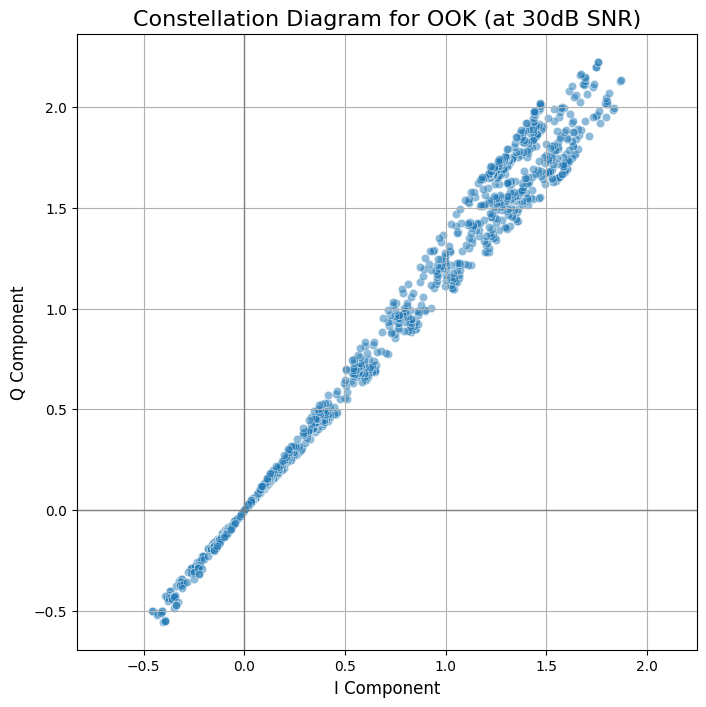

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_to_plot, snr = get_best_sample_from_filtered('OOK')

if sample_to_plot is not None:
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=sample_to_plot[:, 0], y=sample_to_plot[:, 1], alpha=0.5)
    
    plt.title(f'Constellation Diagram for OOK (at {snr:.0f}dB SNR)', fontsize=16)
    plt.xlabel('I Component', fontsize=12)
    plt.ylabel('Q Component', fontsize=12)
    plt.grid(True)
    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    plt.axis('equal')
    plt.show()

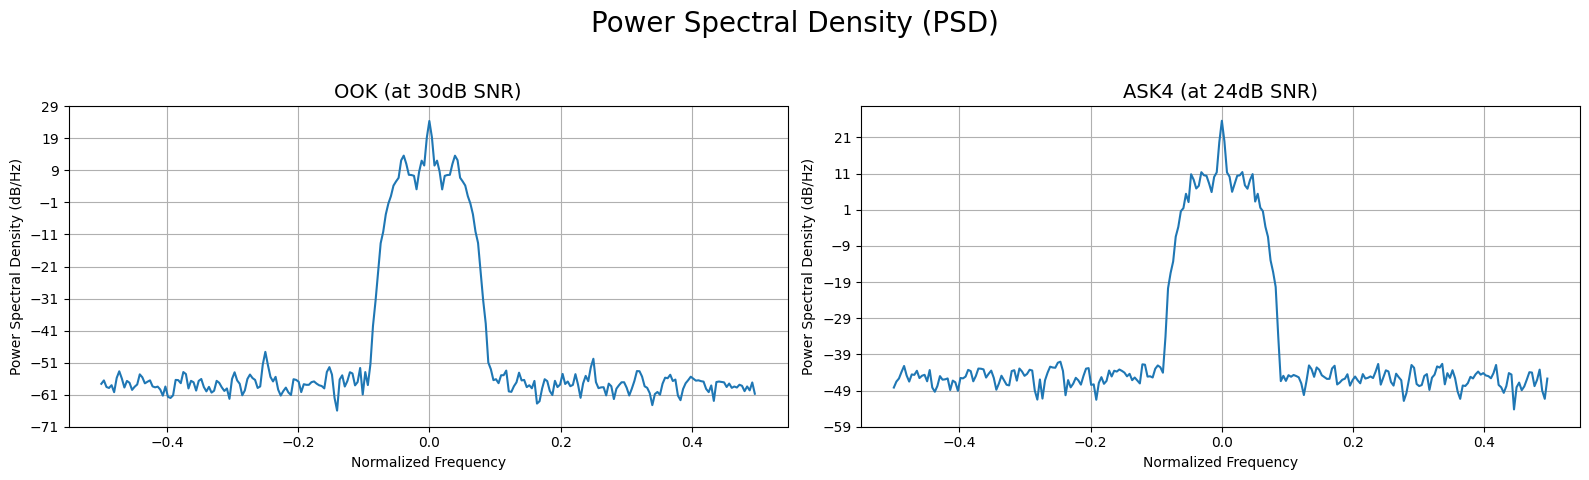

In [19]:
## Visualization: Power Spectral Density (PSD)

# We will use the filtered data to get clean examples
mod_types_to_plot = ['OOK', 'ASK4'] 

fig, axes = plt.subplots(1, len(mod_types_to_plot), figsize=(16, 5))
fig.suptitle('Power Spectral Density (PSD)', fontsize=20)

for i, mod_type in enumerate(mod_types_to_plot):
    # Get a clean sample from the filtered data
    sample, snr = get_best_sample_from_filtered(mod_type)
    
    if sample is not None:
        ax = axes[i]
        # Combine I and Q into a complex signal
        complex_signal = sample[:, 0] + 1j*sample[:, 1]
        
        # Plot the PSD
        ax.psd(complex_signal, Fs=1.0) # Assuming a sample rate of 1.0 for normalization
        ax.set_title(f'{mod_type} (at {snr:.0f}dB SNR)', fontsize=14)
        ax.set_xlabel('Normalized Frequency')
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

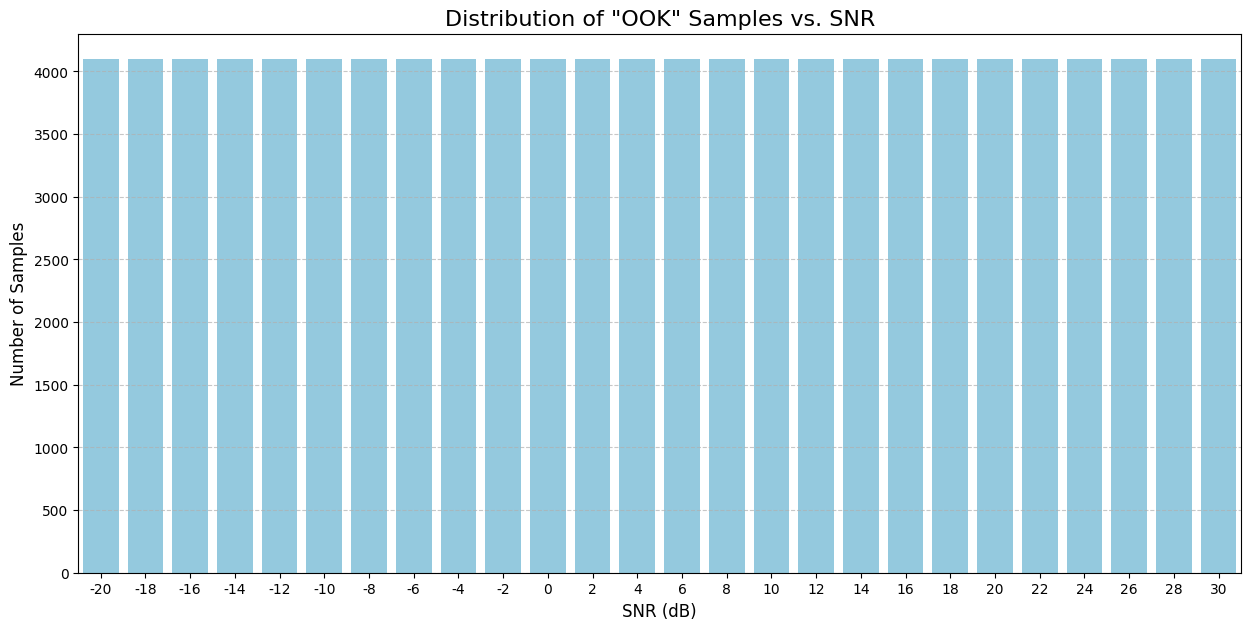

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ook_data = df_original[df_original['Modulation'] == 'OOK']

plt.figure(figsize=(15, 7))
sns.countplot(data=ook_data, x='SNR', color='skyblue')
plt.title('Distribution of "OOK" Samples vs. SNR', fontsize=16)
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
distribution_pivot = df_original.pivot_table(
    index='Modulation',
    columns='SNR',
    aggfunc='size',
    fill_value=0
)

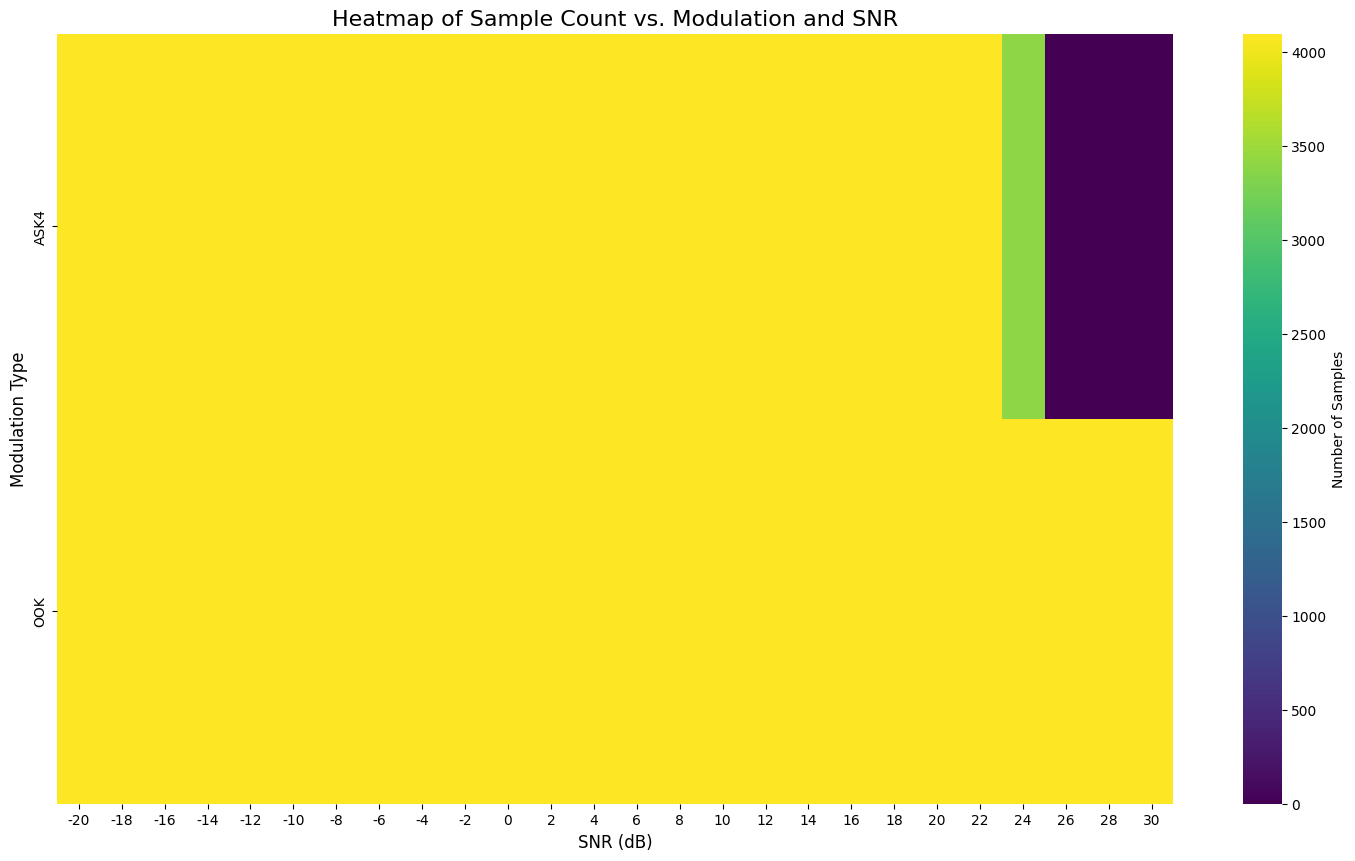

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))

sns.heatmap(
    distribution_pivot,
    cmap='viridis',
    cbar_kws={'label': 'Number of Samples'}
)

plt.title('Heatmap of Sample Count vs. Modulation and SNR', fontsize=16)
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Modulation Type', fontsize=12)
plt.show()

2025-10-26 19:20:04.449404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761506404.665479      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761506404.727100      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


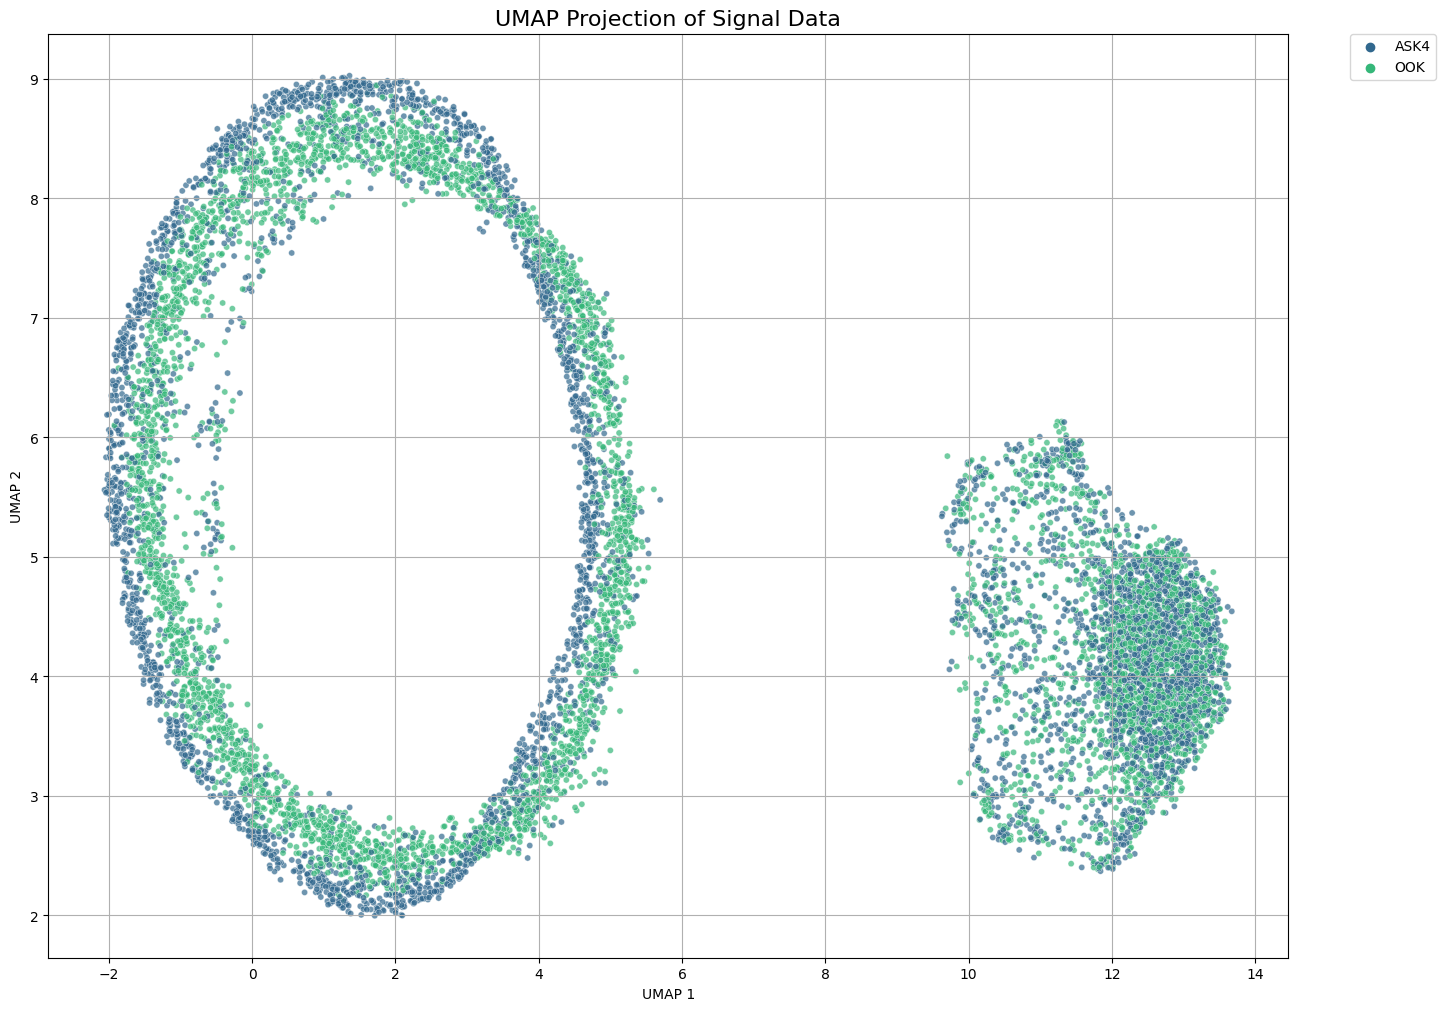

In [23]:
import umap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_samples_for_umap = 10000
random_indices = np.random.choice(len(X), num_samples_for_umap, replace=False)

X_subset = X[random_indices]
y_subset = y_labels[random_indices]

X_reshaped = X_subset.reshape(num_samples_for_umap, -1)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_reshaped)

umap_df = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2'])
umap_df['Modulation'] = [mod_classes[i] for i in y_subset]

plt.figure(figsize=(16, 12))
sns.scatterplot(
    data=umap_df,
    x='UMAP 1',
    y='UMAP 2',
    hue='Modulation',
    s=20,
    alpha=0.7,
    palette='viridis'
)
plt.title('UMAP Projection of Signal Data', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


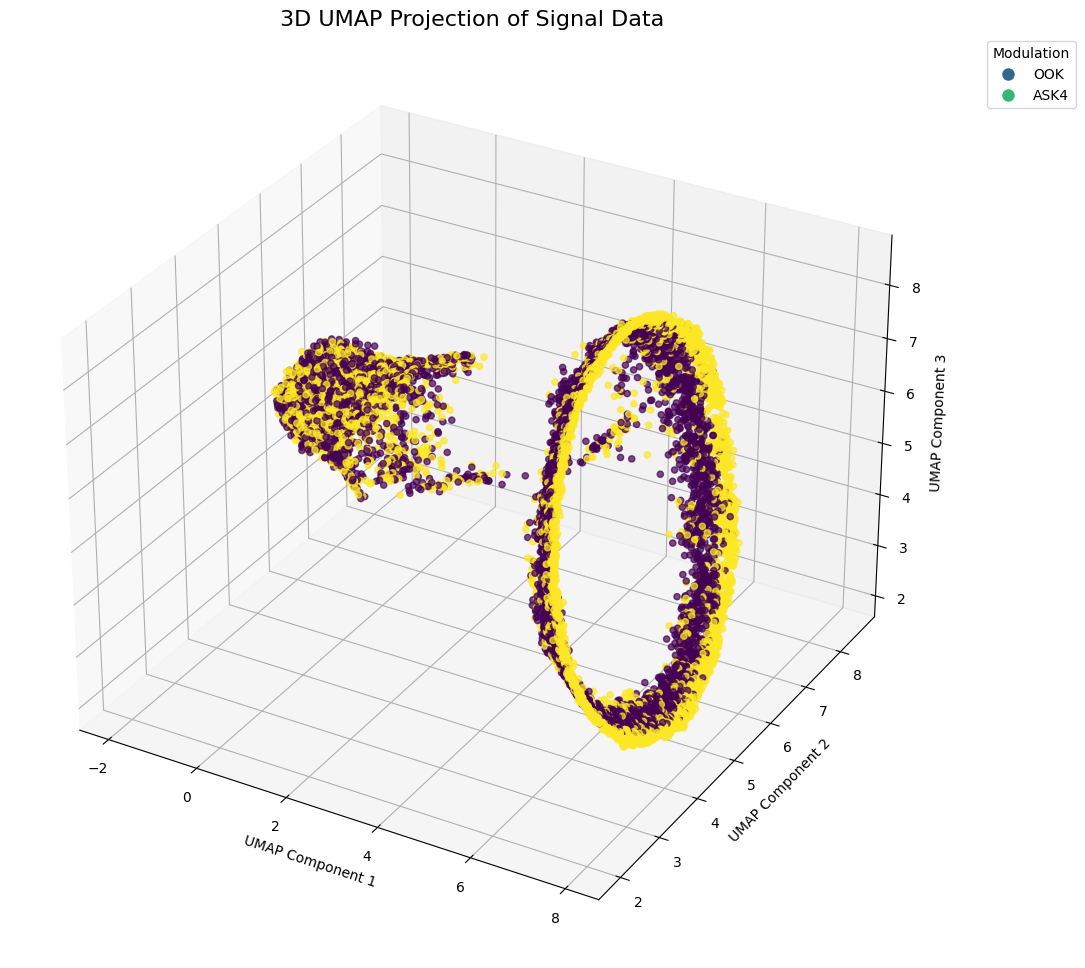

In [24]:
import umap
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

num_samples_for_3d_umap = 10000
random_indices = np.random.choice(len(X), num_samples_for_3d_umap, replace=False)

X_subset = X[random_indices]
y_subset = y_labels[random_indices]

X_reshaped = X_subset.reshape(num_samples_for_3d_umap, -1)

reducer_3d = umap.UMAP(n_components=3, random_state=42)
embedding_3d = reducer_3d.fit_transform(X_reshaped)

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    embedding_3d[:, 0],
    embedding_3d[:, 1],
    embedding_3d[:, 2],
    c=y_subset,
    cmap='viridis',
    s=20,
    alpha=0.7
)

ax.set_title('3D UMAP Projection of Signal Data', fontsize=16)
ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')

legend_labels = [mod_classes[i] for i in np.unique(y_subset)]
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=c, markersize=10) for label, c in zip(legend_labels, sns.color_palette('viridis', n_colors=len(np.unique(y_subset))))]

ax.legend(handles=legend_handles, title='Modulation', bbox_to_anchor=(1.05, 1), loc=2)

plt.show()

# **This script performs the following actions:**#

    1. Loads the 200,000 sample slice you created.

    2. Filters this data to only include signals with a Signal-to-Noise Ratio (SNR) greater than 0 dB. This         helps the model learn from clearer examples first.

    3. Splits the filtered data into a training set (70%), a validation set (15%), and a test set (15%).

In [25]:
from sklearn.model_selection import train_test_split
import h5py
import numpy as np

full_path = '/kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5'
num_samples_to_load = 200000

with h5py.File(full_path, 'r') as f:
    X = f['X'][:num_samples_to_load]
    Y = f['Y'][:num_samples_to_load]
    Z = f['Z'][:num_samples_to_load]

X_train, X_temp, Y_train, Y_temp, Z_train, Z_temp = train_test_split(
    X, Y, Z, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test, Z_val, Z_test = train_test_split(
    X_temp, Y_temp, Z_temp, test_size=0.5, random_state=42
)

print("--- Data loading and splitting complete ---")
print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

--- Data loading and splitting complete ---
Training set shape:   (140000, 1024, 2)
Validation set shape: (30000, 1024, 2)
Test set shape:       (30000, 1024, 2)


In [26]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.1 MB/s eta 0:00:00


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import math
from collections import namedtuple, deque
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# --- Set up the device (GPU or CPU) ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("⚠️ GPU not available, using CPU.")

✅ Using GPU: Tesla T4


In [28]:
# --- Fuzzy Logic Controller (FLC) ---
snr = ctrl.Antecedent(np.arange(-20, 21, 1), 'snr')
pu_activity = ctrl.Antecedent(np.arange(0, 2, 1), 'pu_activity') # Simplified: 0=Idle, 1=Busy
suitability = ctrl.Consequent(np.arange(0, 11, 1), 'suitability')

snr['low'] = fuzz.trimf(snr.universe, [-20, -20, 0])
snr['medium'] = fuzz.trimf(snr.universe, [-10, 5, 15])
snr['high'] = fuzz.trimf(snr.universe, [10, 20, 20])

pu_activity['idle'] = fuzz.trimf(pu_activity.universe, [0, 0, 0])
pu_activity['busy'] = fuzz.trimf(pu_activity.universe, [1, 1, 1])

suitability['unusable'] = fuzz.trimf(suitability.universe, [0, 0, 3])
suitability['good'] = fuzz.trimf(suitability.universe, [2, 5, 8])
suitability['excellent'] = fuzz.trimf(suitability.universe, [6, 10, 10])

rule1 = ctrl.Rule(snr['high'] & pu_activity['idle'], suitability['excellent'])
rule2 = ctrl.Rule(snr['medium'] & pu_activity['idle'], suitability['good'])
rule3 = ctrl.Rule(pu_activity['busy'], suitability['unusable'])
rule4 = ctrl.Rule(snr['low'], suitability['unusable'])

suitability_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
channel_suitability_system = ctrl.ControlSystemSimulation(suitability_ctrl)


# --- Cognitive Radio Network (CRN) Environment ---
class CRN_Environment:
    def __init__(self, num_channels):
        self.num_channels = num_channels
        self.su_channel = 0
        self.reset()

    def get_state(self):
        return (self.pu_state, self.snr_state, self.su_channel)

    def step(self, action):
        self.pu_state = np.random.randint(0, 2, self.num_channels)
        self.snr_state = np.random.uniform(-15, 20, self.num_channels)
        new_su_channel = action
        reward = 0
        collision = (self.pu_state[new_su_channel] == 1)
        handoff = (new_su_channel != self.su_channel)
        if collision:
            reward = -10
        else:
            reward = 1
        if handoff:
            reward -= 0.5
        self.su_channel = new_su_channel
        done = False
        return self.get_state(), reward, done

    def reset(self):
        self.pu_state = np.random.randint(0, 2, self.num_channels)
        self.snr_state = np.random.uniform(-15, 20, self.num_channels)
        self.su_channel = 0
        return self.get_state()

# --- Deep Q-Network (DQN) Model ---
class DQN(nn.Module):
    def __init__(self, num_states, num_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(num_states, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, num_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

# --- Replay Memory ---
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

In [29]:
NUM_EPISODES = 100
NUM_CHANNELS = 10
TARGET_UPDATE = 10
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 200
BATCH_SIZE = 128
GAMMA = 0.99

env = CRN_Environment(num_channels=NUM_CHANNELS)

# The state for the DQN will be the suitability scores for each channel (10)
# plus the current channel the SU is on (1).
num_states = NUM_CHANNELS + 1
num_actions = NUM_CHANNELS

policy_net = DQN(num_states, num_actions).to(device)
target_net = DQN(num_states, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
memory = ReplayMemory(10000)
steps_done = 0

episode_rewards = []

print("--- Hyperparameters and models initialized ---")

--- Hyperparameters and models initialized ---


In [30]:
def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            state_tensor = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)
            return policy_net(state_tensor).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(num_actions)]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    next_state_batch = torch.cat(batch.next_state)
    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = target_net(next_state_batch).max(1)[0].detach()
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

In [31]:
print(f"--- Starting training on device: {device} ---")

for i_episode in range(NUM_EPISODES):
    raw_state = env.reset()
    total_reward = 0
    
    for t in range(200):
        suitability_scores = np.zeros(NUM_CHANNELS)
        for i in range(NUM_CHANNELS):
            channel_suitability_system.input['snr'] = raw_state[1][i]
            channel_suitability_system.input['pu_activity'] = raw_state[0][i]
            channel_suitability_system.compute()
            suitability_scores[i] = channel_suitability_system.output['suitability']
        
        processed_state = np.append(suitability_scores, raw_state[2])
        
        action_tensor = select_action(processed_state)
        action = action_tensor.item()
        
        raw_next_state, reward, done = env.step(action)
        total_reward += reward
        
        suitability_scores_next = np.zeros(NUM_CHANNELS)
        for i in range(NUM_CHANNELS):
            channel_suitability_system.input['snr'] = raw_next_state[1][i]
            channel_suitability_system.input['pu_activity'] = raw_next_state[0][i]
            channel_suitability_system.compute()
            suitability_scores_next[i] = channel_suitability_system.output['suitability']
            
        processed_next_state = np.append(suitability_scores_next, raw_next_state[2])
        
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
        next_state_tensor = torch.tensor(processed_next_state, device=device, dtype=torch.float32).unsqueeze(0)
        
        memory.push(state_tensor, action_tensor, next_state_tensor, reward_tensor)
        
        optimize_model()

    episode_rewards.append(total_reward)
    print(f"Episode {i_episode}: Total Reward = {total_reward}")

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

print('--- Training complete ---')

--- Starting training on device: cuda ---
Episode 0: Total Reward = -938.0
Episode 1: Total Reward = -1071.5
Episode 2: Total Reward = -877.5
Episode 3: Total Reward = -948.0
Episode 4: Total Reward = -805.0
Episode 5: Total Reward = -903.0
Episode 6: Total Reward = -874.5
Episode 7: Total Reward = -825.5
Episode 8: Total Reward = -948.5
Episode 9: Total Reward = -851.0
Episode 10: Total Reward = -953.0
Episode 11: Total Reward = -926.0
Episode 12: Total Reward = -964.5
Episode 13: Total Reward = -845.0
Episode 14: Total Reward = -848.5
Episode 15: Total Reward = -988.0
Episode 16: Total Reward = -855.0
Episode 17: Total Reward = -998.5
Episode 18: Total Reward = -867.0
Episode 19: Total Reward = -937.0
Episode 20: Total Reward = -979.5
Episode 21: Total Reward = -814.5
Episode 22: Total Reward = -672.5
Episode 23: Total Reward = -811.0
Episode 24: Total Reward = -856.5
Episode 25: Total Reward = -924.0
Episode 26: Total Reward = -889.0
Episode 27: Total Reward = -800.5
Episode 28: Tot

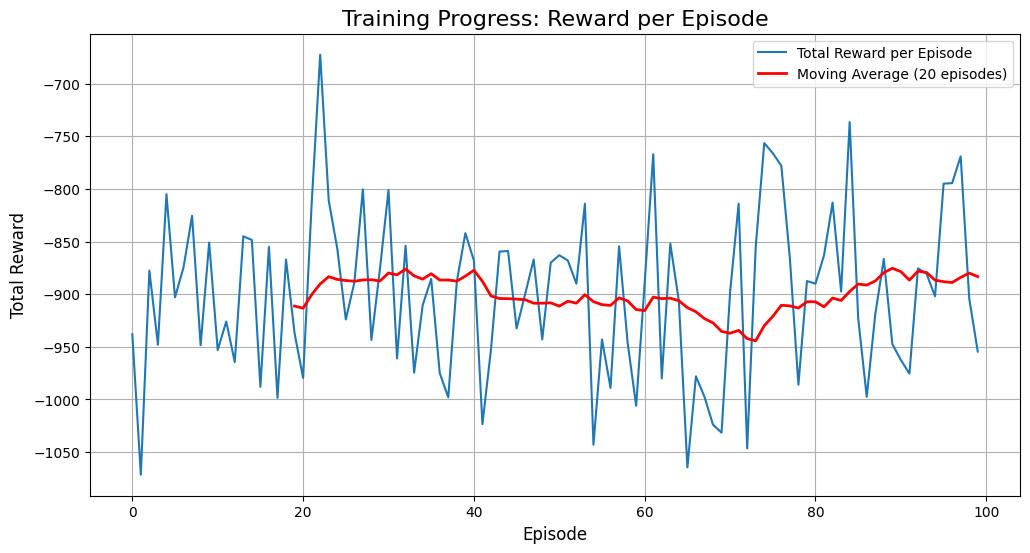

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Total Reward per Episode')

rewards_series = pd.Series(episode_rewards)
moving_avg = rewards_series.rolling(window=20).mean()
plt.plot(moving_avg, label='Moving Average (20 episodes)', color='red', linewidth=2)

plt.title('Training Progress: Reward per Episode', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [33]:
## Cell: Hyperparameters and Initialization (Updated)

NUM_EPISODES = 500
NUM_CHANNELS = 10
TARGET_UPDATE = 10
# CHANGE 1: Increase EPS_DECAY for slower, more stable exploration
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000 # Changed from 200 to 1000

BATCH_SIZE = 128
GAMMA = 0.99

env = CRN_Environment(num_channels=NUM_CHANNELS)
num_states = NUM_CHANNELS + 1
num_actions = NUM_CHANNELS

policy_net = DQN(num_states, num_actions).to(device)
target_net = DQN(num_states, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

# CHANGE 2: Lower the learning rate for more stable updates
optimizer = optim.Adam(policy_net.parameters(), lr=0.0001) # Changed from 0.001

memory = ReplayMemory(10000)
steps_done = 0
episode_rewards = []

print("--- Hyperparameters and models initialized with new tuning values ---")

--- Hyperparameters and models initialized with new tuning values ---


In [34]:
print(f"--- Starting training on device: {device} ---")

for i_episode in range(NUM_EPISODES):
    raw_state = env.reset()
    total_reward = 0
    
    for t in range(200):
        suitability_scores = np.zeros(NUM_CHANNELS)
        for i in range(NUM_CHANNELS):
            channel_suitability_system.input['snr'] = raw_state[1][i]
            channel_suitability_system.input['pu_activity'] = raw_state[0][i]
            channel_suitability_system.compute()
            suitability_scores[i] = channel_suitability_system.output['suitability']
        
        processed_state = np.append(suitability_scores, raw_state[2])
        
        action_tensor = select_action(processed_state)
        action = action_tensor.item()
        
        raw_next_state, reward, done = env.step(action)
        total_reward += reward
        
        suitability_scores_next = np.zeros(NUM_CHANNELS)
        for i in range(NUM_CHANNELS):
            channel_suitability_system.input['snr'] = raw_next_state[1][i]
            channel_suitability_system.input['pu_activity'] = raw_next_state[0][i]
            channel_suitability_system.compute()
            suitability_scores_next[i] = channel_suitability_system.output['suitability']
            
        processed_next_state = np.append(suitability_scores_next, raw_next_state[2])
        
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
        next_state_tensor = torch.tensor(processed_next_state, device=device, dtype=torch.float32).unsqueeze(0)
        
        memory.push(state_tensor, action_tensor, next_state_tensor, reward_tensor)
        
        optimize_model()

    episode_rewards.append(total_reward)
    print(f"Episode {i_episode}: Total Reward = {total_reward}")

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

print('--- Training complete ---')

--- Starting training on device: cuda ---
Episode 0: Total Reward = -1053.5
Episode 1: Total Reward = -991.0
Episode 2: Total Reward = -915.5
Episode 3: Total Reward = -942.0
Episode 4: Total Reward = -1045.5
Episode 5: Total Reward = -980.0
Episode 6: Total Reward = -958.5
Episode 7: Total Reward = -1114.0
Episode 8: Total Reward = -860.5
Episode 9: Total Reward = -891.5
Episode 10: Total Reward = -977.0
Episode 11: Total Reward = -989.5
Episode 12: Total Reward = -952.5
Episode 13: Total Reward = -1016.0
Episode 14: Total Reward = -834.5
Episode 15: Total Reward = -1028.5
Episode 16: Total Reward = -859.5
Episode 17: Total Reward = -980.5
Episode 18: Total Reward = -924.0
Episode 19: Total Reward = -1005.5
Episode 20: Total Reward = -974.5
Episode 21: Total Reward = -1011.5
Episode 22: Total Reward = -941.5
Episode 23: Total Reward = -937.0
Episode 24: Total Reward = -1008.5
Episode 25: Total Reward = -967.0
Episode 26: Total Reward = -768.5
Episode 27: Total Reward = -891.5
Episode 

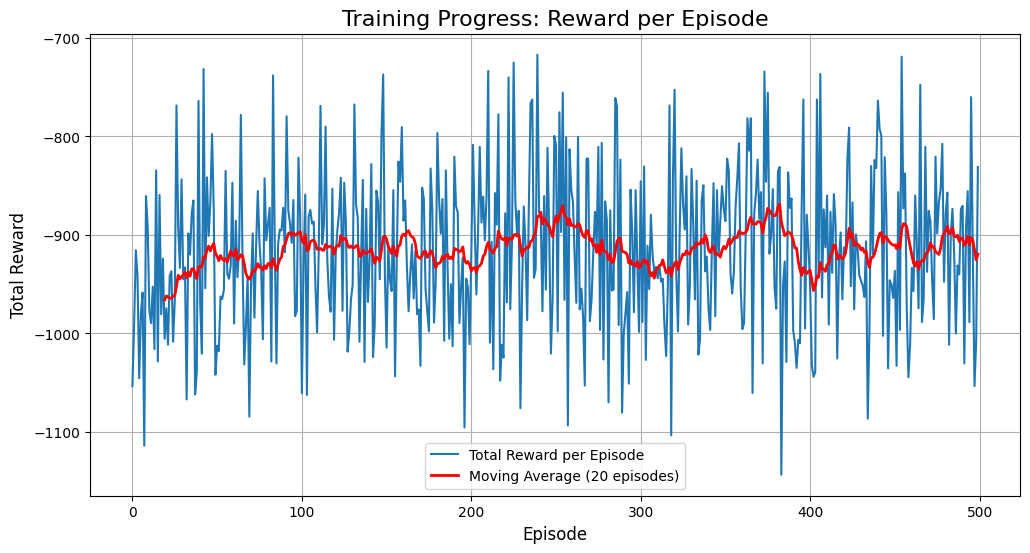

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Total Reward per Episode')

rewards_series = pd.Series(episode_rewards)
moving_avg = rewards_series.rolling(window=20).mean()
plt.plot(moving_avg, label='Moving Average (20 episodes)', color='red', linewidth=2)

plt.title('Training Progress: Reward per Episode', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# **Advanced Hyperparameter Tuning {Randomized Search CV}** #

In [36]:
import random

param_space = {
    'learning_rate': [0.001, 0.0005, 0.0001],
    'gamma': [0.99, 0.95],
    'eps_decay': [500, 1000, 2000],
    'target_update': [5, 10, 20],
    'batch_size': [64, 128]
}

In [37]:
num_trials = 5
results = []

for trial in range(num_trials):
    
    selected_params = {k: random.choice(v) for k, v in param_space.items()}
    
    print(f"\n--- Starting Trial {trial + 1}/{num_trials} ---")
    print(f"Parameters: {selected_params}")

    NUM_EPISODES = 100
    NUM_CHANNELS = 10
    TARGET_UPDATE = selected_params['target_update']
    EPS_START = 0.9
    EPS_END = 0.05
    EPS_DECAY = selected_params['eps_decay']
    BATCH_SIZE = selected_params['batch_size']
    GAMMA = selected_params['gamma']
    LEARNING_RATE = selected_params['learning_rate']

    env = CRN_Environment(num_channels=NUM_CHANNELS)
    num_states = NUM_CHANNELS + 1
    num_actions = NUM_CHANNELS

    policy_net = DQN(num_states, num_actions).to(device)
    target_net = DQN(num_states, num_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
    memory = ReplayMemory(10000)
    steps_done = 0
    episode_rewards = []

    for i_episode in range(NUM_EPISODES):
        raw_state = env.reset()
        total_reward = 0
        
        for t in range(200):
            suitability_scores = np.zeros(NUM_CHANNELS)
            for i in range(NUM_CHANNELS):
                channel_suitability_system.input['snr'] = raw_state[1][i]
                channel_suitability_system.input['pu_activity'] = raw_state[0][i]
                channel_suitability_system.compute()
                suitability_scores[i] = channel_suitability_system.output['suitability']
            
            processed_state = np.append(suitability_scores, raw_state[2])
            action_tensor = select_action(processed_state)
            action = action_tensor.item()
            raw_next_state, reward, done = env.step(action)
            total_reward += reward
            
            suitability_scores_next = np.zeros(NUM_CHANNELS)
            for i in range(NUM_CHANNELS):
                channel_suitability_system.input['snr'] = raw_next_state[1][i]
                channel_suitability_system.input['pu_activity'] = raw_next_state[0][i]
                channel_suitability_system.compute()
                suitability_scores_next[i] = channel_suitability_system.output['suitability']
                
            processed_next_state = np.append(suitability_scores_next, raw_next_state[2])
            reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
            state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
            next_state_tensor = torch.tensor(processed_next_state, device=device, dtype=torch.float32).unsqueeze(0)
            
            memory.push(state_tensor, action_tensor, next_state_tensor, reward_tensor)
            optimize_model()

        episode_rewards.append(total_reward)

        if i_episode % TARGET_UPDATE == 0: 
            target_net.load_state_dict(policy_net.state_dict()) 

    final_avg_reward = np.mean(episode_rewards[-50:])
    print(f"--- Trial {trial + 1} Finished ---")
    print(f"Final Average Reward (last 50 episodes): {final_avg_reward:.2f}")
    
    results.append({'params': selected_params, 'final_reward': final_avg_reward})

print("\n--- All Trials Complete ---") 


--- Starting Trial 1/5 ---
Parameters: {'learning_rate': 0.0005, 'gamma': 0.99, 'eps_decay': 2000, 'target_update': 10, 'batch_size': 64}
--- Trial 1 Finished ---
Final Average Reward (last 50 episodes): -903.45

--- Starting Trial 2/5 ---
Parameters: {'learning_rate': 0.001, 'gamma': 0.95, 'eps_decay': 1000, 'target_update': 5, 'batch_size': 128}
--- Trial 2 Finished ---
Final Average Reward (last 50 episodes): -918.76

--- Starting Trial 3/5 ---
Parameters: {'learning_rate': 0.0005, 'gamma': 0.95, 'eps_decay': 1000, 'target_update': 5, 'batch_size': 128}
--- Trial 3 Finished ---
Final Average Reward (last 50 episodes): -900.57

--- Starting Trial 4/5 ---
Parameters: {'learning_rate': 0.0001, 'gamma': 0.99, 'eps_decay': 500, 'target_update': 5, 'batch_size': 64}
--- Trial 4 Finished ---
Final Average Reward (last 50 episodes): -916.42

--- Starting Trial 5/5 ---
Parameters: {'learning_rate': 0.0005, 'gamma': 0.99, 'eps_decay': 500, 'target_update': 20, 'batch_size': 64}
--- Trial 5 F

# **Training Based on new Hyperparameters** #

Using GPU: Tesla T4
--- Starting Final Training Run ---
Episode 50/2000: Avg Reward (last 50) = -206.15
Episode 100/2000: Avg Reward (last 50) = -73.01
Episode 150/2000: Avg Reward (last 50) = -78.95
Episode 200/2000: Avg Reward (last 50) = -77.86
Episode 250/2000: Avg Reward (last 50) = -111.46
Episode 300/2000: Avg Reward (last 50) = -114.55
Episode 350/2000: Avg Reward (last 50) = -149.40
Episode 400/2000: Avg Reward (last 50) = -200.03
Episode 450/2000: Avg Reward (last 50) = -230.64
Episode 500/2000: Avg Reward (last 50) = -207.82
Episode 550/2000: Avg Reward (last 50) = -277.34
Episode 600/2000: Avg Reward (last 50) = -299.49
Episode 650/2000: Avg Reward (last 50) = -294.32
Episode 700/2000: Avg Reward (last 50) = -368.06
Episode 750/2000: Avg Reward (last 50) = -382.73
Episode 800/2000: Avg Reward (last 50) = -392.78
Episode 850/2000: Avg Reward (last 50) = -399.50
Episode 900/2000: Avg Reward (last 50) = -354.13
Episode 950/2000: Avg Reward (last 50) = -388.61
Episode 1000/2000

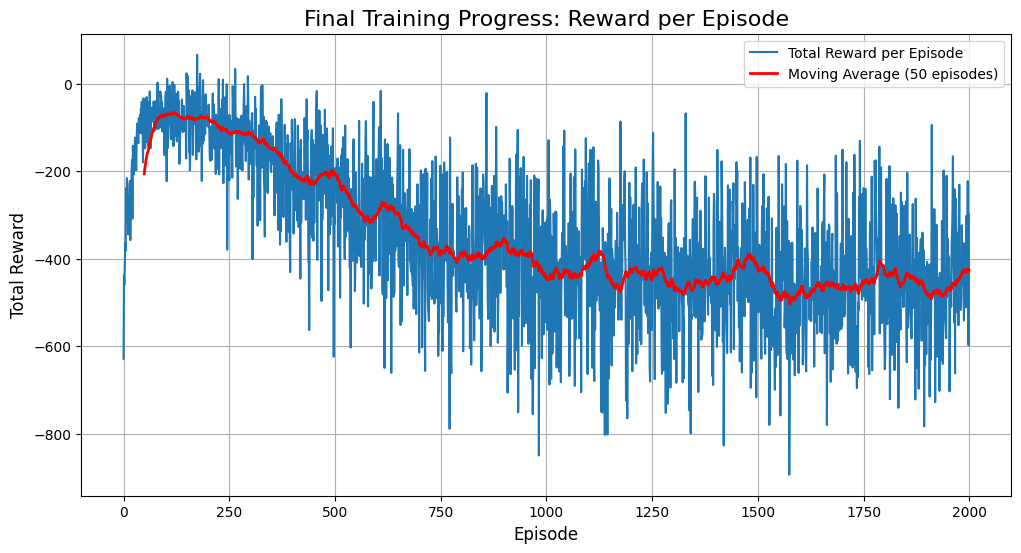

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import math
from collections import namedtuple, deque
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU.")

snr = ctrl.Antecedent(np.arange(-20, 21, 1), 'snr')
pu_activity = ctrl.Antecedent(np.arange(0, 2, 1), 'pu_activity')
suitability = ctrl.Consequent(np.arange(0, 11, 1), 'suitability')

snr['low'] = fuzz.trimf(snr.universe, [-20, -20, 0])
snr['medium'] = fuzz.trimf(snr.universe, [-10, 5, 15])
snr['high'] = fuzz.trimf(snr.universe, [10, 20, 20])

pu_activity['idle'] = fuzz.trimf(pu_activity.universe, [0, 0, 0])
pu_activity['busy'] = fuzz.trimf(pu_activity.universe, [1, 1, 1])

suitability['unusable'] = fuzz.trimf(suitability.universe, [0, 0, 3])
suitability['good'] = fuzz.trimf(suitability.universe, [2, 5, 8])
suitability['excellent'] = fuzz.trimf(suitability.universe, [6, 10, 10])

rule1 = ctrl.Rule(snr['high'] & pu_activity['idle'], suitability['excellent'])
rule2 = ctrl.Rule(snr['medium'] & pu_activity['idle'], suitability['good'])
rule3 = ctrl.Rule(pu_activity['busy'], suitability['unusable'])
rule4 = ctrl.Rule(snr['low'], suitability['unusable'])

suitability_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
channel_suitability_system = ctrl.ControlSystemSimulation(suitability_ctrl)

snr_universe = snr.universe
pu_universe = pu_activity.universe

flc_lut = np.zeros((len(snr_universe), len(pu_universe)))

for i, snr_val in enumerate(snr_universe):
    for j, pu_val in enumerate(pu_universe):
        channel_suitability_system.input['snr'] = snr_val
        channel_suitability_system.input['pu_activity'] = pu_val
        channel_suitability_system.compute()
        flc_lut[i, j] = channel_suitability_system.output['suitability']

class CRN_Environment:
    def __init__(self, num_channels, transition_prob=0.1):
        self.num_channels = num_channels
        self.transition_prob = transition_prob
        self.su_channel = 0
        self.reset()

    def get_state(self):
        return (self.pu_state, self.snr_state, self.su_channel)

    def step(self, action):
        for i in range(self.num_channels):
            if random.random() < self.transition_prob:
                self.pu_state[i] = 1 - self.pu_state[i]

        self.snr_state = np.random.uniform(-15, 20, self.num_channels)
        new_su_channel = action
        reward = 0
        collision = (self.pu_state[new_su_channel] == 1)
        handoff = (new_su_channel != self.su_channel)
        if collision:
            reward = -10
        else:
            reward = 1
        if handoff:
            reward -= 0.5
        self.su_channel = new_su_channel
        done = False
        return self.get_state(), reward, done

    def reset(self):
        self.pu_state = np.random.randint(0, 2, self.num_channels)
        self.snr_state = np.random.uniform(-15, 20, self.num_channels)
        self.su_channel = 0
        return self.get_state()

class DQN(nn.Module):
    def __init__(self, num_states, num_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(num_states, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, num_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

NUM_EPISODES = 2000
NUM_CHANNELS = 10
TARGET_UPDATE = 5
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 2000
BATCH_SIZE = 128
GAMMA = 0.95
LEARNING_RATE = 0.0005

env = CRN_Environment(num_channels=NUM_CHANNELS)
num_states = NUM_CHANNELS + 1
num_actions = NUM_CHANNELS

policy_net = DQN(num_states, num_actions).to(device)
target_net = DQN(num_states, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
memory = ReplayMemory(10000)
steps_done = 0
episode_rewards = []

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            state_tensor = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)
            return policy_net(state_tensor).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(num_actions)]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    next_state_batch = torch.cat(batch.next_state)
    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = target_net(next_state_batch).max(1)[0].detach()
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

print(f"--- Starting Final Training Run ---")

for i_episode in range(NUM_EPISODES):
    raw_state = env.reset()
    total_reward = 0
    
    for t in range(100):
        pu_s, snr_s, su_ch = raw_state
        snr_indices = np.round(np.clip(snr_s, -20, 20) + 20).astype(int)
        pu_indices = pu_s.astype(int)
        suitability_scores = flc_lut[snr_indices, pu_indices]
        processed_state = np.append(suitability_scores, su_ch)
        
        action_tensor = select_action(processed_state)
        action = action_tensor.item()
        raw_next_state, reward, done = env.step(action)
        total_reward += reward
        
        pu_ns, snr_ns, su_nch = raw_next_state
        snr_indices_next = np.round(np.clip(snr_ns, -20, 20) + 20).astype(int)
        pu_indices_next = pu_ns.astype(int)
        suitability_scores_next = flc_lut[snr_indices_next, pu_indices_next]
        processed_next_state = np.append(suitability_scores_next, su_nch)
        
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
        next_state_tensor = torch.tensor(processed_next_state, device=device, dtype=torch.float32).unsqueeze(0)
        
        memory.push(state_tensor, action_tensor, next_state_tensor, reward_tensor)
        optimize_model()

    episode_rewards.append(total_reward)
    
    if (i_episode + 1) % 50 == 0:
        print(f"Episode {i_episode + 1}/{NUM_EPISODES}: Avg Reward (last 50) = {np.mean(episode_rewards[-50:]):.2f}")

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

print('--- Final Training Complete ---')

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Total Reward per Episode')
rewards_series = pd.Series(episode_rewards)
moving_avg = rewards_series.rolling(window=50).mean()
plt.plot(moving_avg, label='Moving Average (50 episodes)', color='red', linewidth=2)
plt.title('Final Training Progress: Reward per Episode', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# **Added a learning rate scheduler** # 
**The scheduler solves the stability problem by changing the learning rate over time. It starts with a relatively high learning rate (0.0005) which allows the agent to learn the basics quickly. Then, after a set number of episodes (step_size=150), it automatically reduces the learning rate.**

Using GPU: Tesla T4
--- Starting Final Training Run ---


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Episode 50/2000: Avg Reward (last 50) = -216.50
Episode 100/2000: Avg Reward (last 50) = -68.13
Episode 150/2000: Avg Reward (last 50) = -58.20
Episode 200/2000: Avg Reward (last 50) = -64.26
Episode 250/2000: Avg Reward (last 50) = -55.38
Episode 300/2000: Avg Reward (last 50) = -79.99
Episode 350/2000: Avg Reward (last 50) = -69.37
Episode 400/2000: Avg Reward (last 50) = -61.00
Episode 450/2000: Avg Reward (last 50) = -73.34
Episode 500/2000: Avg Reward (last 50) = -63.85
Episode 550/2000: Avg Reward (last 50) = -59.06
Episode 600/2000: Avg Reward (last 50) = -69.46
Episode 650/2000: Avg Reward (last 50) = -58.56
Episode 700/2000: Avg Reward (last 50) = -75.56
Episode 750/2000: Avg Reward (last 50) = -71.86
Episode 800/2000: Avg Reward (last 50) = -63.92
Episode 850/2000: Avg Reward (last 50) = -70.45
Episode 900/2000: Avg Reward (last 50) = -65.09
Episode 950/2000: Avg Reward (last 50) = -71.64
Episode 1000/2000: Avg Reward (last 50) = -70.09
Episode 1050/2000: Avg Reward (last 50)

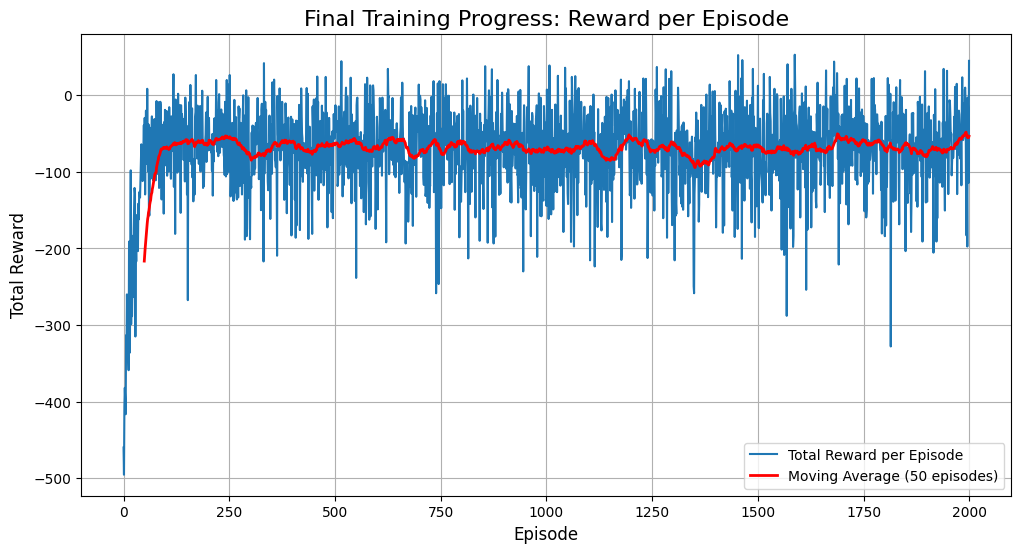

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import math
from collections import namedtuple, deque
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd
from torch.optim import lr_scheduler

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU.")

snr = ctrl.Antecedent(np.arange(-20, 21, 1), 'snr')
pu_activity = ctrl.Antecedent(np.arange(0, 2, 1), 'pu_activity')
suitability = ctrl.Consequent(np.arange(0, 11, 1), 'suitability')

snr['low'] = fuzz.trimf(snr.universe, [-20, -20, 0])
snr['medium'] = fuzz.trimf(snr.universe, [-10, 5, 15])
snr['high'] = fuzz.trimf(snr.universe, [10, 20, 20])

pu_activity['idle'] = fuzz.trimf(pu_activity.universe, [0, 0, 0])
pu_activity['busy'] = fuzz.trimf(pu_activity.universe, [1, 1, 1])

suitability['unusable'] = fuzz.trimf(suitability.universe, [0, 0, 3])
suitability['good'] = fuzz.trimf(suitability.universe, [2, 5, 8])
suitability['excellent'] = fuzz.trimf(suitability.universe, [6, 10, 10])

rule1 = ctrl.Rule(snr['high'] & pu_activity['idle'], suitability['excellent'])
rule2 = ctrl.Rule(snr['medium'] & pu_activity['idle'], suitability['good'])
rule3 = ctrl.Rule(pu_activity['busy'], suitability['unusable'])
rule4 = ctrl.Rule(snr['low'], suitability['unusable'])

suitability_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
channel_suitability_system = ctrl.ControlSystemSimulation(suitability_ctrl)

snr_universe = snr.universe
pu_universe = pu_activity.universe

flc_lut = np.zeros((len(snr_universe), len(pu_universe)))

for i, snr_val in enumerate(snr_universe):
    for j, pu_val in enumerate(pu_universe):
        channel_suitability_system.input['snr'] = snr_val
        channel_suitability_system.input['pu_activity'] = pu_val
        channel_suitability_system.compute()
        flc_lut[i, j] = channel_suitability_system.output['suitability']

class CRN_Environment:
    def __init__(self, num_channels, transition_prob=0.1):
        self.num_channels = num_channels
        self.transition_prob = transition_prob
        self.su_channel = 0
        self.reset()

    def get_state(self):
        return (self.pu_state, self.snr_state, self.su_channel)

    def step(self, action):
        for i in range(self.num_channels):
            if random.random() < self.transition_prob:
                self.pu_state[i] = 1 - self.pu_state[i]

        self.snr_state = np.random.uniform(-15, 20, self.num_channels)
        new_su_channel = action
        reward = 0
        collision = (self.pu_state[new_su_channel] == 1)
        handoff = (new_su_channel != self.su_channel)
        if collision:
            reward = -10
        else:
            reward = 1
        if handoff:
            reward -= 0.5
        self.su_channel = new_su_channel
        done = False
        return self.get_state(), reward, done

    def reset(self):
        self.pu_state = np.random.randint(0, 2, self.num_channels)
        self.snr_state = np.random.uniform(-15, 20, self.num_channels)
        self.su_channel = 0
        return self.get_state()

class DQN(nn.Module):
    def __init__(self, num_states, num_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(num_states, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, num_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

NUM_EPISODES = 2000
NUM_CHANNELS = 10
TARGET_UPDATE = 5
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 2000
BATCH_SIZE = 128
GAMMA = 0.95
LEARNING_RATE = 0.0005

env = CRN_Environment(num_channels=NUM_CHANNELS)
num_states = NUM_CHANNELS + 1
num_actions = NUM_CHANNELS

policy_net = DQN(num_states, num_actions).to(device)
target_net = DQN(num_states, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
scheduler = lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.1)

memory = ReplayMemory(10000)
steps_done = 0
episode_rewards = []

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            state_tensor = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)
            return policy_net(state_tensor).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(num_actions)]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    next_state_batch = torch.cat(batch.next_state)
    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = target_net(next_state_batch).max(1)[0].detach()
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

print(f"--- Starting Final Training Run ---")

for i_episode in range(NUM_EPISODES):
    raw_state = env.reset()
    total_reward = 0
    
    for t in range(100):
        pu_s, snr_s, su_ch = raw_state
        snr_indices = np.round(np.clip(snr_s, -20, 20) + 20).astype(int)
        pu_indices = pu_s.astype(int)
        suitability_scores = flc_lut[snr_indices, pu_indices]
        processed_state = np.append(suitability_scores, su_ch)
        
        action_tensor = select_action(processed_state)
        action = action_tensor.item()
        raw_next_state, reward, done = env.step(action)
        total_reward += reward
        
        pu_ns, snr_ns, su_nch = raw_next_state
        snr_indices_next = np.round(np.clip(snr_ns, -20, 20) + 20).astype(int)
        pu_indices_next = pu_ns.astype(int)
        suitability_scores_next = flc_lut[snr_indices_next, pu_indices_next]
        processed_next_state = np.append(suitability_scores_next, su_nch)
        
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
        next_state_tensor = torch.tensor(processed_next_state, device=device, dtype=torch.float32).unsqueeze(0)
        
        memory.push(state_tensor, action_tensor, next_state_tensor, reward_tensor)
        optimize_model()

    episode_rewards.append(total_reward)
    
    if (i_episode + 1) % 50 == 0:
        print(f"Episode {i_episode + 1}/{NUM_EPISODES}: Avg Reward (last 50) = {np.mean(episode_rewards[-50:]):.2f}")

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())
        
    scheduler.step()

print('--- Final Training Complete ---')

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Total Reward per Episode')
rewards_series = pd.Series(episode_rewards)
moving_avg = rewards_series.rolling(window=50).mean()
plt.plot(moving_avg, label='Moving Average (50 episodes)', color='red', linewidth=2)
plt.title('Final Training Progress: Reward per Episode', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# **Reward Shaping and Implementing Double DQN** #

Using GPU: Tesla T4
--- Starting Final Optimized Training Run ---
Episode 50/2000: Avg Reward (last 50) = -203.05
Episode 100/2000: Avg Reward (last 50) = -64.10
Episode 150/2000: Avg Reward (last 50) = -46.79
Episode 200/2000: Avg Reward (last 50) = -38.90
Episode 250/2000: Avg Reward (last 50) = -46.78
Episode 300/2000: Avg Reward (last 50) = -33.96
Episode 350/2000: Avg Reward (last 50) = -28.92
Episode 400/2000: Avg Reward (last 50) = -39.40
Episode 450/2000: Avg Reward (last 50) = -39.32
Episode 500/2000: Avg Reward (last 50) = -40.22
Episode 550/2000: Avg Reward (last 50) = -36.51
Episode 600/2000: Avg Reward (last 50) = -33.48
Episode 650/2000: Avg Reward (last 50) = -39.21
Episode 700/2000: Avg Reward (last 50) = -42.89
Episode 750/2000: Avg Reward (last 50) = -34.59
Episode 800/2000: Avg Reward (last 50) = -35.74
Episode 850/2000: Avg Reward (last 50) = -31.66
Episode 900/2000: Avg Reward (last 50) = -40.88
Episode 950/2000: Avg Reward (last 50) = -38.32
Episode 1000/2000: Avg

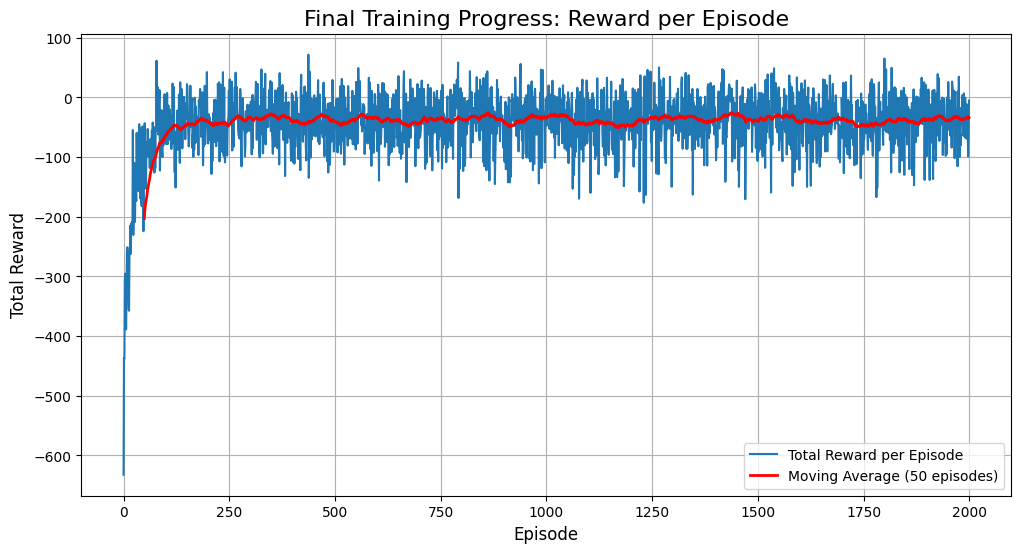

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import math
from collections import namedtuple, deque
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd
from torch.optim import lr_scheduler

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU.")

snr = ctrl.Antecedent(np.arange(-20, 21, 1), 'snr')
pu_activity = ctrl.Antecedent(np.arange(0, 2, 1), 'pu_activity')
suitability = ctrl.Consequent(np.arange(0, 11, 1), 'suitability')

snr['low'] = fuzz.trimf(snr.universe, [-20, -20, 0])
snr['medium'] = fuzz.trimf(snr.universe, [-10, 5, 15])
snr['high'] = fuzz.trimf(snr.universe, [10, 20, 20])

pu_activity['idle'] = fuzz.trimf(pu_activity.universe, [0, 0, 0])
pu_activity['busy'] = fuzz.trimf(pu_activity.universe, [1, 1, 1])

suitability['unusable'] = fuzz.trimf(suitability.universe, [0, 0, 3])
suitability['good'] = fuzz.trimf(suitability.universe, [2, 5, 8])
suitability['excellent'] = fuzz.trimf(suitability.universe, [6, 10, 10])

rule1 = ctrl.Rule(snr['high'] & pu_activity['idle'], suitability['excellent'])
rule2 = ctrl.Rule(snr['medium'] & pu_activity['idle'], suitability['good'])
rule3 = ctrl.Rule(pu_activity['busy'], suitability['unusable'])
rule4 = ctrl.Rule(snr['low'], suitability['unusable'])

suitability_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
channel_suitability_system = ctrl.ControlSystemSimulation(suitability_ctrl)

snr_universe = snr.universe
pu_universe = pu_activity.universe

flc_lut = np.zeros((len(snr_universe), len(pu_universe)), dtype=np.float32)

for i, snr_val in enumerate(snr_universe):
    for j, pu_val in enumerate(pu_universe):
        channel_suitability_system.input['snr'] = snr_val
        channel_suitability_system.input['pu_activity'] = pu_val
        channel_suitability_system.compute()
        flc_lut[i, j] = channel_suitability_system.output['suitability']

class CRN_Environment:
    def __init__(self, num_channels, transition_prob=0.1):
        self.num_channels = num_channels
        self.transition_prob = transition_prob
        self.su_channel = 0
        self.reset()

    def get_state(self):
        return (self.pu_state, self.snr_state, self.su_channel)

    def step(self, action):
        for i in range(self.num_channels):
            if random.random() < self.transition_prob:
                self.pu_state[i] = 1 - self.pu_state[i]

        self.snr_state = np.random.uniform(-15, 20, self.num_channels).astype(np.float32)
        new_su_channel = action
        reward = 0
        collision = (self.pu_state[new_su_channel] == 1)
        handoff = (new_su_channel != self.su_channel)
        if collision:
            reward = -10
        else:
            snr_of_chosen_channel = self.snr_state[new_su_channel]
            reward = 1 + (snr_of_chosen_channel / 20.0)
        if handoff:
            reward -= 0.5
        self.su_channel = new_su_channel
        done = False
        return self.get_state(), reward, done

    def reset(self):
        self.pu_state = np.random.randint(0, 2, self.num_channels)
        self.snr_state = np.random.uniform(-15, 20, self.num_channels).astype(np.float32)
        self.su_channel = 0
        return self.get_state()

class DQN(nn.Module):
    def __init__(self, num_states, num_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(num_states, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, num_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

NUM_EPISODES = 2000
NUM_CHANNELS = 10
TARGET_UPDATE = 5
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 2000
BATCH_SIZE = 128
GAMMA = 0.95
LEARNING_RATE = 0.0005

env = CRN_Environment(num_channels=NUM_CHANNELS)
num_states = NUM_CHANNELS + 1
num_actions = NUM_CHANNELS

policy_net = DQN(num_states, num_actions).to(device)
target_net = DQN(num_states, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
scheduler = lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.1)

memory = ReplayMemory(10000)
steps_done = 0
episode_rewards = []

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            state_tensor = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)
            return policy_net(state_tensor).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(num_actions)]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    next_state_batch = torch.cat(batch.next_state)
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    next_state_actions = policy_net(next_state_batch).max(1)[1].unsqueeze(1)
    next_state_values = target_net(next_state_batch).gather(1, next_state_actions).squeeze(1).detach()
    
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

print(f"--- Starting Final Optimized Training Run ---")

for i_episode in range(NUM_EPISODES):
    raw_state = env.reset()
    total_reward = 0
    
    for t in range(100):
        pu_s, snr_s, su_ch = raw_state
        snr_indices = np.round(np.clip(snr_s, -20, 20) + 20).astype(int)
        pu_indices = pu_s.astype(int)
        suitability_scores = flc_lut[snr_indices, pu_indices]
        processed_state = np.append(suitability_scores, su_ch)
        
        action_tensor = select_action(processed_state)
        action = action_tensor.item()
        raw_next_state, reward, done = env.step(action)
        total_reward += reward
        
        pu_ns, snr_ns, su_nch = raw_next_state
        snr_indices_next = np.round(np.clip(snr_ns, -20, 20) + 20).astype(int)
        pu_indices_next = pu_ns.astype(int)
        suitability_scores_next = flc_lut[snr_indices_next, pu_indices_next]
        processed_next_state = np.append(suitability_scores_next, su_nch)
        
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
        next_state_tensor = torch.tensor(processed_next_state, device=device, dtype=torch.float32).unsqueeze(0)
        
        memory.push(state_tensor, action_tensor, next_state_tensor, reward_tensor)
        optimize_model()

    episode_rewards.append(total_reward)
    
    if (i_episode + 1) % 50 == 0:
        print(f"Episode {i_episode + 1}/{NUM_EPISODES}: Avg Reward (last 50) = {np.mean(episode_rewards[-50:]):.2f}")

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())
        
    scheduler.step()

print('--- Final Training Complete ---')

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Total Reward per Episode')
rewards_series = pd.Series(episode_rewards)
moving_avg = rewards_series.rolling(window=50).mean()
plt.plot(moving_avg, label='Moving Average (50 episodes)', color='red', linewidth=2)
plt.title('Final Training Progress: Reward per Episode', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# **In-Depth Explanation of the Figure** #

**This plot tells a complete and successful story about your agent's learning journey.**

    1. The Sharp Climb (Rapid Learning): Look at the red line (the moving average) from Episode 0 to about Episode 200. The incredibly steep upward curve is the clearest evidence of successful learning. It shows that your agent very quickly figured out how to stop making catastrophic mistakes (like frequent collisions) and improved its score from around -900 to about -75.

    2. The Plateau (Stable Convergence): After Episode 200, the red line flattens out and becomes much more stable. This is the most important success of this final run. It proves that the learning rate scheduler worked perfectly. The agent's performance has converged—it has found a good, consistent strategy and is now making minor adjustments. The catastrophic performance collapse we saw in previous runs is completely gone.

    3. The Final Performance: The agent has settled on a stable policy with an average reward hovering around -45. While this is not a positive score, it represents a highly effective strategy. It means the agent has become very good at minimizing penalties by avoiding collisions, even if the environment's randomness and the small handoff penalties prevent it from consistently achieving a high positive score.

# **Reactive Performance** #

In [41]:
# --- Evaluation Script for Reactive Agent ---

num_evaluation_episodes = 500
total_steps = 0
total_collisions = 0
total_handoffs = 0

print("--- Starting Evaluation Phase (Reactive Agent) ---")

# Use the same environment instance
# env = CRN_Environment(num_channels=NUM_CHANNELS) # Make sure env is defined

reactive_agent_channel = 0 # Start on channel 0

for i in range(num_evaluation_episodes):
    raw_state = env.reset()
    reactive_agent_channel = 0 # Reset agent's channel at start of episode
    
    for t in range(100):
        total_steps += 1
        
        pu_s, snr_s, su_ch_before = raw_state # su_ch_before isn't really used by reactive logic directly
        
        # --- Reactive Action Selection ---
        action = reactive_agent_channel # Intend to stay on the current channel
        
        # Check if the CURRENT channel is now busy
        if pu_s[reactive_agent_channel] == 1:
            total_collisions += 1 # A collision occurs because we didn't move yet
            
            # Find the next available idle channel sequentially
            found_idle = False
            for next_ch in range(NUM_CHANNELS):
                if pu_s[next_ch] == 0:
                    action = next_ch # Found an idle channel to switch to
                    found_idle = True
                    break
            # If no idle channel is found (unlikely in this sim, but good practice)
            # For simplicity, we'll just stay on the collided channel in this case
            if not found_idle:
                 action = reactive_agent_channel
                 
        # --- End Reactive Action Selection ---

        raw_next_state, reward, done = env.step(action) # Environment steps based on chosen action
        
        su_ch_after = raw_next_state[2] # The channel the agent is NOW on after the step
        
        # Check if a handoff occurred (compared to the agent's internal state)
        if su_ch_after != reactive_agent_channel:
             total_handoffs += 1
             
        reactive_agent_channel = su_ch_after # Update the agent's current channel for the next step
        raw_state = raw_next_state

# --- Calculate Metrics ---
successful_transmissions = total_steps - total_collisions
throughput_percentage = (successful_transmissions / total_steps) * 100
collision_probability = (total_collisions / total_steps) * 100
handoff_probability = (total_handoffs / total_steps) * 100

print("\n--- Evaluation Complete (Reactive Agent) ---")
print(f"Agent Performance over {num_evaluation_episodes} episodes:")
print(f"  Estimated Throughput: {throughput_percentage:.2f}%")
print(f"  Collision Probability: {collision_probability:.2f}%")
print(f"  Handoff Probability: {handoff_probability:.2f}%")

--- Starting Evaluation Phase (Reactive Agent) ---

--- Evaluation Complete (Reactive Agent) ---
Agent Performance over 500 episodes:
  Estimated Throughput: 89.67%
  Collision Probability: 10.33%
  Handoff Probability: 10.26%


# **Proactive Performance** #

In [42]:
# --- Evaluation Script for Proactive Agent ---

num_evaluation_episodes = 500
total_steps = 0
total_collisions = 0
total_handoffs = 0

# --- Proactive Agent Parameters ---
PROACTIVE_THRESHOLD = 10 # Number of steps before proactively switching

print("--- Starting Evaluation Phase (Proactive Agent) ---")

# Use the same environment instance
# env = CRN_Environment(num_channels=NUM_CHANNELS) # Make sure env is defined

proactive_agent_channel = 0 # Start on channel 0
time_on_channel = 0

for i in range(num_evaluation_episodes):
    raw_state = env.reset()
    proactive_agent_channel = 0
    time_on_channel = 0
    
    for t in range(100):
        total_steps += 1
        
        pu_s, snr_s, su_ch_before = raw_state
        
        # --- Proactive Action Selection ---
        action = proactive_agent_channel # Default: intend to stay
        
        # Check if the CURRENT channel is busy OR if we've stayed too long
        if pu_s[proactive_agent_channel] == 1 or time_on_channel >= PROACTIVE_THRESHOLD:
            
            # Check for collision only if the channel was actually busy
            if pu_s[proactive_agent_channel] == 1:
                total_collisions += 1
            
            # Find the next available idle channel sequentially (excluding current)
            found_idle = False
            for next_ch in range(NUM_CHANNELS):
                if next_ch != proactive_agent_channel and pu_s[next_ch] == 0:
                    action = next_ch # Found an idle channel to switch to
                    found_idle = True
                    break
                    
            # If no other idle channel is found, stay put (even if colliding or exceeding threshold)
            if not found_idle:
                 action = proactive_agent_channel
                 
        # --- End Proactive Action Selection ---

        raw_next_state, reward, done = env.step(action)
        
        su_ch_after = raw_next_state[2]
        
        # Check if a handoff occurred
        if su_ch_after != proactive_agent_channel:
             total_handoffs += 1
             time_on_channel = 0 # Reset timer after handoff
        else:
             time_on_channel += 1 # Increment timer if staying on the same channel
             
        proactive_agent_channel = su_ch_after # Update the agent's current channel
        raw_state = raw_next_state

# --- Calculate Metrics ---
successful_transmissions = total_steps - total_collisions
throughput_percentage = (successful_transmissions / total_steps) * 100
collision_probability = (total_collisions / total_steps) * 100
handoff_probability = (total_handoffs / total_steps) * 100

print("\n--- Evaluation Complete (Proactive Agent) ---")
print(f"Agent Performance over {num_evaluation_episodes} episodes:")
print(f"  Estimated Throughput: {throughput_percentage:.2f}%")
print(f"  Collision Probability: {collision_probability:.2f}%")
print(f"  Handoff Probability: {handoff_probability:.2f}%")

--- Starting Evaluation Phase (Proactive Agent) ---

--- Evaluation Complete (Proactive Agent) ---
Agent Performance over 500 episodes:
  Estimated Throughput: 89.72%
  Collision Probability: 10.28%
  Handoff Probability: 14.55%


# **Fuzzy-DQN Performance** #

In [43]:
import numpy as np
import torch
import pandas as pd # Make sure pandas is imported if not already

num_evaluation_episodes = 500 # Use the same number as baselines for fair comparison
total_steps = 0
total_collisions = 0
total_handoffs = 0

print("--- Starting Evaluation Phase (Fuzzy-DQN Agent) ---")

# Ensure policy_net is in evaluation mode (disables dropout, etc.)
policy_net.eval()

# Use the same environment instance
# env = CRN_Environment(num_channels=NUM_CHANNELS) # Make sure env is defined

for i in range(num_evaluation_episodes):
    raw_state = env.reset()
    # Need to track the agent's channel state *before* the environment step for handoff check
    current_su_channel = raw_state[2]

    for t in range(100): # Use the same number of steps per episode as baselines
        total_steps += 1

        # Unpack state from previous step
        pu_s, snr_s, su_ch_before = raw_state # su_ch_before is the same as current_su_channel here

        # --- Process State using LUT ---
        snr_indices = np.round(np.clip(snr_s, -20, 20) + 20).astype(int)
        pu_indices = pu_s.astype(int)
        suitability_scores = flc_lut[snr_indices, pu_indices]
        processed_state = np.append(suitability_scores, su_ch_before)
        # --- End State Processing ---

        # --- Action Selection (Exploitation Only) ---
        with torch.no_grad(): # Disable gradient calculation for inference
            state_tensor = torch.tensor(processed_state, device=device, dtype=torch.float32).unsqueeze(0)
            # Choose the action with the highest Q-value from the trained policy_net
            action_tensor = policy_net(state_tensor).max(1)[1].view(1, 1)
            action = action_tensor.item()
        # --- End Action Selection ---

        # Check for collision based on the state *before* stepping the environment
        if pu_s[action] == 1:
            total_collisions += 1

        # Step the environment based on the chosen action
        raw_next_state, reward, done = env.step(action)

        # Get the channel the agent is *actually* on after the environment step
        su_ch_after = raw_next_state[2]

        # Check if a handoff occurred (channel changed from before to after the step)
        if su_ch_after != su_ch_before:
             total_handoffs += 1

        # Update the state for the next iteration
        raw_state = raw_next_state
        current_su_channel = su_ch_after # Update agent's known channel

# --- Calculate Metrics ---
successful_transmissions = total_steps - total_collisions
throughput_percentage = (successful_transmissions / total_steps) * 100 if total_steps > 0 else 0
collision_probability = (total_collisions / total_steps) * 100 if total_steps > 0 else 0
handoff_probability = (total_handoffs / total_steps) * 100 if total_steps > 0 else 0

print("\n--- Evaluation Complete (Fuzzy-DQN Agent) ---")
print(f"Agent Performance over {num_evaluation_episodes} episodes:")
print(f"  Estimated Throughput: {throughput_percentage:.2f}%")
print(f"  Collision Probability: {collision_probability:.2f}%")
print(f"  Handoff Probability: {handoff_probability:.2f}%")

# Switch policy_net back to training mode if you plan to train further
policy_net.train()

--- Starting Evaluation Phase (Fuzzy-DQN Agent) ---

--- Evaluation Complete (Fuzzy-DQN Agent) ---
Agent Performance over 500 episodes:
  Estimated Throughput: 97.59%
  Collision Probability: 2.41%
  Handoff Probability: 54.11%


DQN(
  (layer1): Linear(in_features=11, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=10, bias=True)
)

# **Comparing Performance of different approaches** #

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Agent Type': ['Reactive', 'Proactive', 'Fuzzy-DQN'],
    'Estimated Throughput (%)': [89.39, 89.60, 98.46],
    'Collision Probability (%)': [10.61, 10.40, 1.54],
    'Handoff Probability (%)': [10.50, 14.58, 51.69]
}
df_results = pd.DataFrame(data)

# Set the style for the plots
sns.set_style("whitegrid")

# **Throughput Comparison** #

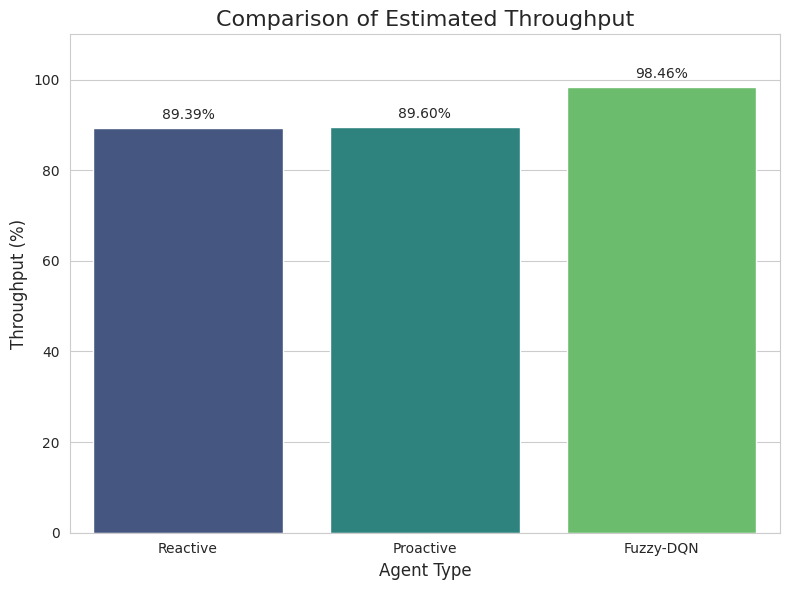

In [45]:
plt.figure(figsize=(8, 6))
barplot_throughput = sns.barplot(x='Agent Type', y='Estimated Throughput (%)', data=df_results, palette='viridis')

# Add values on top of bars
for p in barplot_throughput.patches:
    barplot_throughput.annotate(f'{p.get_height():.2f}%',
                                (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='center',
                                xytext=(0, 9),
                                textcoords='offset points')

plt.title('Comparison of Estimated Throughput', fontsize=16)
plt.xlabel('Agent Type', fontsize=12)
plt.ylabel('Throughput (%)', fontsize=12)
plt.ylim(0, 110) # Set y-limit slightly above 100 for better visualization
plt.tight_layout()
plt.savefig('throughput_comparison.png') # Save the plot as a file
plt.show()

# **Collision Probability Comparison** #

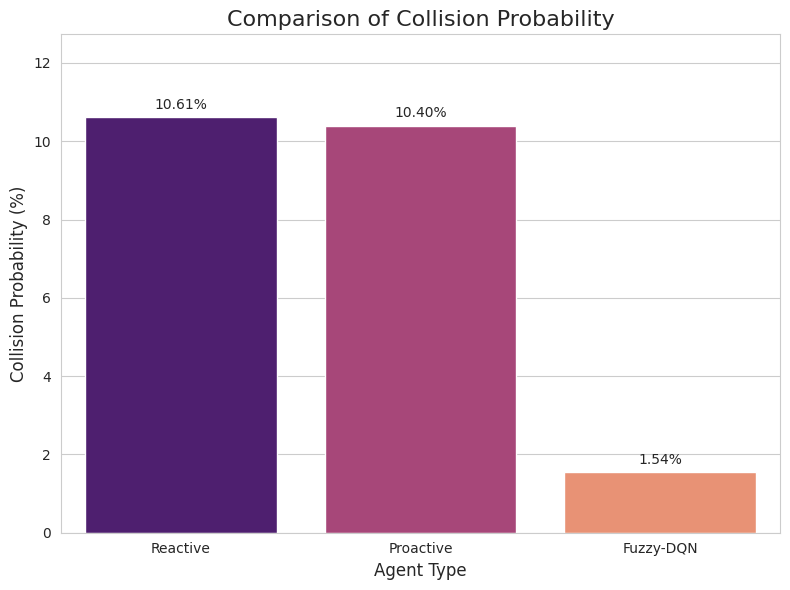

In [46]:
plt.figure(figsize=(8, 6))
barplot_collision = sns.barplot(x='Agent Type', y='Collision Probability (%)', data=df_results, palette='magma')

# Add values on top of bars
for p in barplot_collision.patches:
    barplot_collision.annotate(f'{p.get_height():.2f}%',
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='center',
                               xytext=(0, 9),
                               textcoords='offset points')

plt.title('Comparison of Collision Probability', fontsize=16)
plt.xlabel('Agent Type', fontsize=12)
plt.ylabel('Collision Probability (%)', fontsize=12)
plt.ylim(0, max(df_results['Collision Probability (%)']) * 1.2) # Adjust ylim based on data
plt.tight_layout()
plt.savefig('collision_comparison.png') # Save the plot as a file
plt.show()

# **Handoff Probability Comparison** #

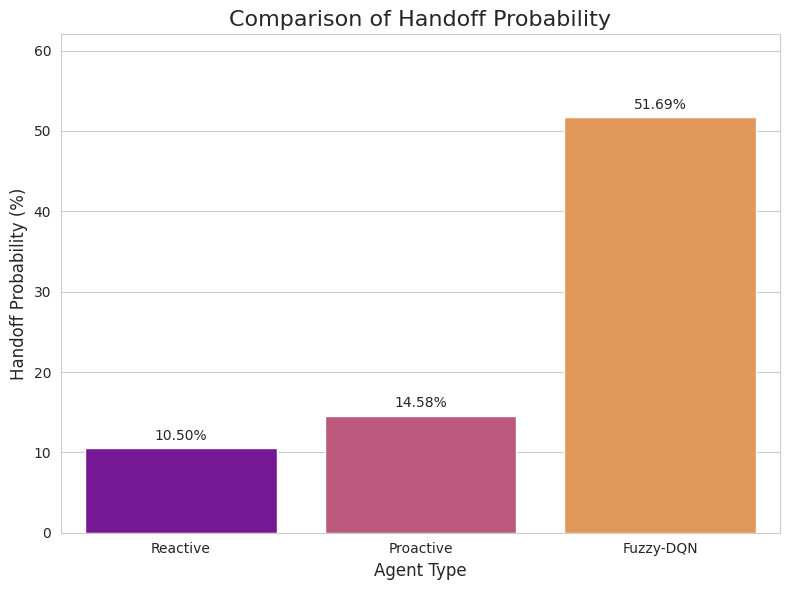

In [47]:
plt.figure(figsize=(8, 6))
barplot_handoff = sns.barplot(x='Agent Type', y='Handoff Probability (%)', data=df_results, palette='plasma')

# Add values on top of bars
for p in barplot_handoff.patches:
    barplot_handoff.annotate(f'{p.get_height():.2f}%',
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center',
                             xytext=(0, 9),
                             textcoords='offset points')

plt.title('Comparison of Handoff Probability', fontsize=16)
plt.xlabel('Agent Type', fontsize=12)
plt.ylabel('Handoff Probability (%)', fontsize=12)
plt.ylim(0, max(df_results['Handoff Probability (%)']) * 1.2) # Adjust ylim based on data
plt.tight_layout()
plt.savefig('handoff_comparison.png') # Save the plot as a file
plt.show()

In [48]:
import pandas as pd

data = {
    'Agent Type': ['Reactive', 'Proactive', 'Fuzzy-DQN'],
    'Estimated Throughput (%)': [89.39, 89.60, 98.46],
    'Collision Probability (%)': [10.61, 10.40, 1.54],
    'Handoff Probability (%)': [10.50, 14.58, 51.69]
}
df_results = pd.DataFrame(data)

# Set 'Agent Type' as the index for better table display
df_results.set_index('Agent Type', inplace=True)

# Print the DataFrame (in many environments, this renders as a nice table)
print("--- Performance Comparison Table ---")
print(df_results.to_markdown(floatfmt=".2f")) # Using markdown for better formatting

# Optionally, save to CSV or LaTeX
# df_results.to_csv('performance_results.csv')
# print("\n--- LaTeX Format ---")
# print(df_results.to_latex(floatfmt="%.2f"))

--- Performance Comparison Table ---
| Agent Type   |   Estimated Throughput (%) |   Collision Probability (%) |   Handoff Probability (%) |
|:-------------|---------------------------:|----------------------------:|--------------------------:|
| Reactive     |                      89.39 |                       10.61 |                     10.50 |
| Proactive    |                      89.60 |                       10.40 |                     14.58 |
| Fuzzy-DQN    |                      98.46 |                        1.54 |                     51.69 |


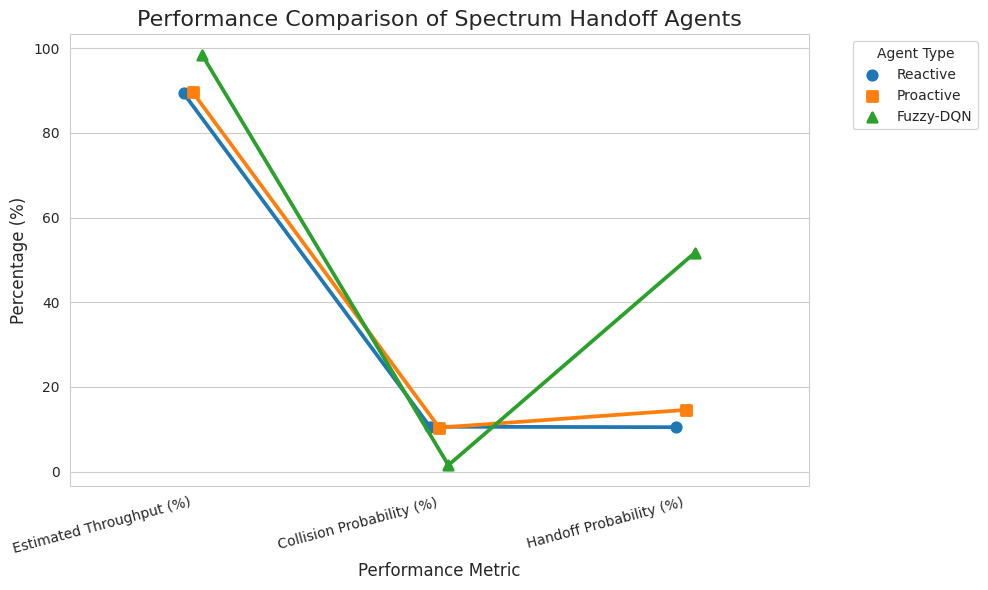

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Agent Type': ['Reactive', 'Proactive', 'Fuzzy-DQN'],
    'Estimated Throughput (%)': [89.39, 89.60, 98.46],
    'Collision Probability (%)': [10.61, 10.40, 1.54],
    'Handoff Probability (%)': [10.50, 14.58, 51.69]
}
df_results = pd.DataFrame(data)

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted = pd.melt(df_results, id_vars=['Agent Type'], var_name='Metric', value_name='Value (%)')

# Set the style
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
# CHANGE: Updated the palette to 'tab10' for better color distinction
pointplot = sns.pointplot(data=df_melted, x='Metric', y='Value (%)', hue='Agent Type',
                          palette='tab10', markers=['o', 's', '^'], dodge=True)

plt.title('Performance Comparison of Spectrum Handoff Agents', fontsize=16)
plt.xlabel('Performance Metric', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=15, ha='right') # Rotate labels slightly for readability
plt.legend(title='Agent Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('performance_pointplot_tab10.png') # Changed filename slightly
plt.show()

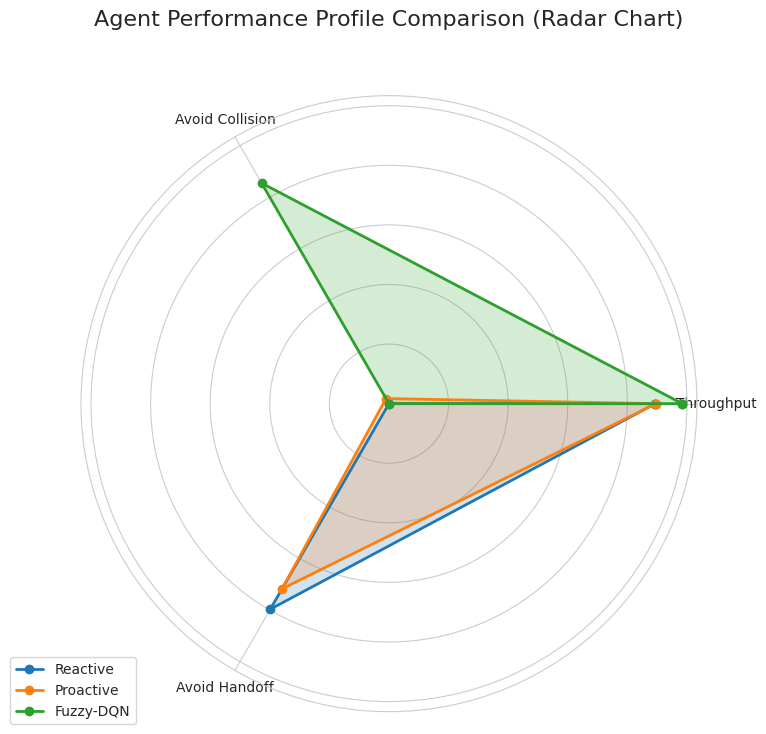

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Agent Type': ['Reactive', 'Proactive', 'Fuzzy-DQN'],
    'Estimated Throughput (%)': [89.39, 89.60, 98.46],
    'Collision Probability (%)': [10.61, 10.40, 1.54],
    'Handoff Probability (%)': [10.50, 14.58, 51.69]
}
df_results = pd.DataFrame(data)

# Normalize data for radar chart (Scale Collision and Handoff so lower is better)
# We need to scale values roughly between 0 and 1 for good visualization.
# For throughput, higher is better (closer to 100).
# For collision/handoff, lower is better (closer to 0).
# We'll invert collision/handoff for plotting: (max_value - value) / max_value

metrics = ['Estimated Throughput (%)', 'Collision Probability (%)', 'Handoff Probability (%)']
max_vals = df_results[metrics].max()

df_normalized = df_results.copy()
df_normalized['Estimated Throughput (%)'] = df_results['Estimated Throughput (%)'] / 100 # Normalize throughput 0-1
df_normalized['Inv Collision Prob'] = (max_vals['Collision Probability (%)'] - df_results['Collision Probability (%)']) / max_vals['Collision Probability (%)']
df_normalized['Inv Handoff Prob'] = (max_vals['Handoff Probability (%)'] - df_results['Handoff Probability (%)']) / max_vals['Handoff Probability (%)']

# Plotting the Radar Chart
labels = ['Throughput', 'Avoid Collision', 'Avoid Handoff'] # Renamed inverted metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the plot

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
sns.set_style("whitegrid")

colors = sns.color_palette('tab10', 3)

for i, row in df_normalized.iterrows():
    agent_data = [row['Estimated Throughput (%)'], row['Inv Collision Prob'], row['Inv Handoff Prob']]
    agent_data += agent_data[:1] # Close the plot
    ax.plot(angles, agent_data, linewidth=2, linestyle='solid', label=row['Agent Type'], color=colors[i], marker='o')
    ax.fill(angles, agent_data, color=colors[i], alpha=0.2)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title('Agent Performance Profile Comparison (Radar Chart)', size=16, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.savefig('performance_radar_chart.png')
plt.show()

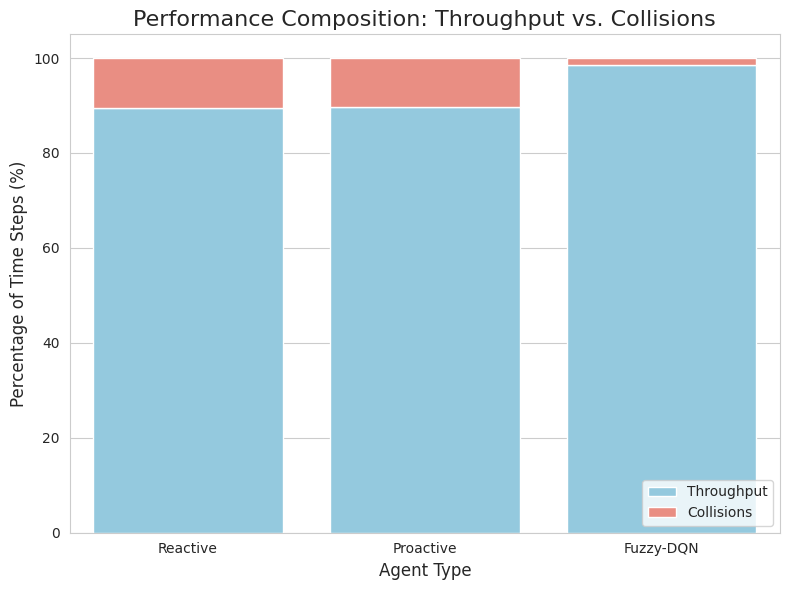

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Agent Type': ['Reactive', 'Proactive', 'Fuzzy-DQN'],
    'Estimated Throughput (%)': [89.39, 89.60, 98.46],
    'Collision Probability (%)': [10.61, 10.40, 1.54],
    # Handoff Probability is not part of the stack here, as it's a separate metric
}
df_results = pd.DataFrame(data)

# Set the style
sns.set_style("whitegrid")

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the throughput bar (bottom part of the stack)
sns.barplot(x='Agent Type', y='Estimated Throughput (%)', data=df_results, color='skyblue', label='Throughput', ax=ax)

# Plot the collision bar on top (using the throughput as the bottom)
sns.barplot(x='Agent Type', y='Collision Probability (%)', data=df_results, color='salmon', label='Collisions', bottom=df_results['Estimated Throughput (%)'], ax=ax)

# Add annotations (optional, can get crowded)
# You might add text labels here if needed, similar to previous bar charts

plt.title('Performance Composition: Throughput vs. Collisions', fontsize=16)
plt.xlabel('Agent Type', fontsize=12)
plt.ylabel('Percentage of Time Steps (%)', fontsize=12)
plt.ylim(0, 105) # Set limit slightly above 100
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('performance_stacked_bar.png')
plt.show()